# CAB420, Sequences
Dr Simon Denman (s.denman@qut.edu.au)

## Overview

This example revisits sequences, and in particular processing sequences with deep learning. Here we'll look at two applications:
* A short-term forecasting task, where we'll try to predict the next value in sequence. For this, we'll use some data from Walmart and try to predict sales. Our input will be the sales each week for the previous 12 weeks, alongside the temperature (because somethings are bought more at different times of year) and CPI for the same time period, and we'll also include the department ID as an additional input.
* A long(er)-term task, where we'll predict the future path of a pedestrian. Here, we'll simply give the model the first path of the trajectory, and get it to predict the rest.

For both tasks, we'll consider four models:
* A LSTM network, with two stacked LSTM layers
* A Bi-directional LSTM network, again with two stacked LSTMs
* A Bi-directional LSTM network, where there's a simple attention mechanism sitting in between the two LSTMs
* A transformer based approach, using two transformer layers stacked together

As with other summary examples, we're re-using a lot of code from elsewhere. Primarily, we're borrowing from the following:
* `08_Sequences/CAB420_Sequences_Example_1_Recurrent_Neural_Networks.ipynb`
* `08_Sequences/CAB420_Sequences_Example_2_Sequence_to_Sequence_Prediction.ipynb`
* `08_Sequences/CAB420_Sequences_Example_3_Attention_and_RNNs.ipynb`
* `09_Transformers/CAB420_Transformers_Example_1_Transformers.ipynb`

In [1]:
import os
# why is this here? This is disabling some tensorflow warning I get in some of my environments that 
# annoy me (look ugly and untidy really)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas
import matplotlib.pyplot as plt
import numpy
import glob
import tensorflow as tf

import keras
from keras.preprocessing.sequence import pad_sequences
from keras.models import Model
from keras import layers

import scipy.io

E0000 00:00:1742620204.041104     171 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742620204.044949     171 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Part 1: Forecasting Walmart Sales (Sequence to One Prediction)

We'll start with the Walmart data. This data has weekly sales data for individual departments in individual stores. Alongside the actual sales, there's a bunch of other context info First a quick visual.

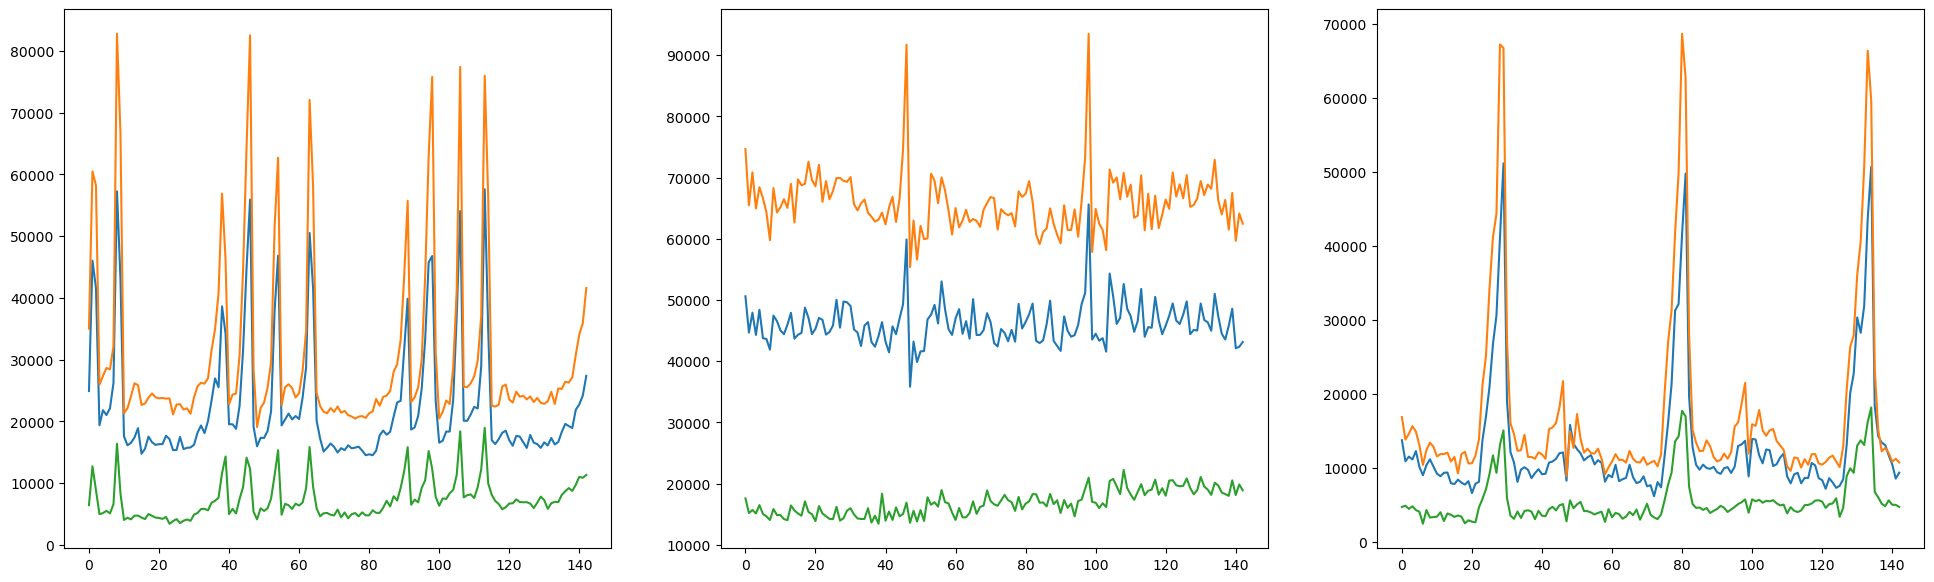

In [2]:
data = pandas.read_csv('../data/walmart/walmart_cleaned.csv')
data['Date'] = pandas.to_datetime(data['Date'], format="%Y-%m-%d")

fig = plt.figure(figsize=[24, 7])    

# qq-plot
ax = fig.add_subplot(1, 3, 1)
ax.plot(data[(data['Store'] == 1) & (data['Dept'] == 1)]['Weekly_Sales'].to_numpy())
ax.plot(data[(data['Store'] == 2) & (data['Dept'] == 1)]['Weekly_Sales'].to_numpy())
ax.plot(data[(data['Store'] == 3) & (data['Dept'] == 1)]['Weekly_Sales'].to_numpy())

ax = fig.add_subplot(1, 3, 2)
ax.plot(data[(data['Store'] == 1) & (data['Dept'] == 2)]['Weekly_Sales'].to_numpy())
ax.plot(data[(data['Store'] == 2) & (data['Dept'] == 2)]['Weekly_Sales'].to_numpy())
ax.plot(data[(data['Store'] == 3) & (data['Dept'] == 2)]['Weekly_Sales'].to_numpy())

ax = fig.add_subplot(1, 3, 3)
ax.plot(data[(data['Store'] == 1) & (data['Dept'] == 3)]['Weekly_Sales'].to_numpy())
ax.plot(data[(data['Store'] == 2) & (data['Dept'] == 3)]['Weekly_Sales'].to_numpy())
ax.plot(data[(data['Store'] == 3) & (data['Dept'] == 3)]['Weekly_Sales'].to_numpy())

The plots show the same department in different stores. We see fairly similar trends across stores, but different volumes of sales in each. Intuitively, this makes sense as different stores will service different size markets, but the same underlying factors (time of year, etc) will lead to similar overall shopping patterns.

In terms of splitting our data, there are different ways that we could do this. Two options are we split by store and try to predict performance in unique stores, or we could split by time and try to predict performance in the future. We'll go with the later, but the data splitting function below will allow for either. 

We'll consider an input length of 12 weeks (3 months), and try to predict the next week. The data spans most of 2010-2012. We'll take the first 18 months (up to the middle of 2011) as the training set, the rest of 2011 as the validation set, and all of 2012 as the testing set. Inputs wise, we'll use the prior sales data, temperature (which may give us a sense of time-of-year or other seasonal effects) and CPI (which would help measure consumer confidence and maybe give a sense of disposable imcome) as the inputs, and simply try to predict the next weekly sales value.

In [3]:
input_length = 12
output_length = 1
train_date = numpy.datetime64("2011-06-30")
val_date = numpy.datetime64("2011-12-31")

in_cols = ['Weekly_Sales', 'Temperature', 'CPI']
out_cols = ['Weekly_Sales']

stores = data['Store'].unique()

train_data = data[data['Date'] <= train_date]
val_data = data[(data['Date'] > train_date) & (data['Date'] <= val_date)]
test_data = data[data['Date'] > val_date]

# Extract sequences from the wallmart data for training
#  data:          data to extract from
#  input length:  number of timesteps to capture in the input
#  output length: number of timesteps to capture in the output
#  in_cols:       input columns to use
#  out_cols:      output columns to use
#  stores:        extract only from these stores, if None extract from all stores. Can be used to split data
#                 by stores
#  scale:         standardise a sample based on the input data
#
#  returns:       arrays of input samples, output samples, and the department and store for each sample
def extract_sequences(data, input_length, output_length, in_cols, out_cols, stores = None, scale = True): 

    # storage
    in_seq = []
    dept = []
    store = []
    out_seq = []

    # do we have specific stores to extract from? If not, pull from all
    if (stores is None):
        stores = data['Store'].unique()

    # iterate through stores
    for s in stores:
        # pull out data for this store
        store_data = data[data['Store'] == s]

        # get departments and iterate through each department
        departments = store_data['Dept'].unique()
        for d in departments:
            # pull out data for each department
            department_data = store_data[store_data['Dept'] == d]
            c = 0
            # loop through data for this department for this store, pulling out (input_length+output_length) samples at a time
            while (c + input_length + output_length) < department_data.shape[0]:
                # grab input data
                i = department_data[in_cols][c:c + input_length].to_numpy()
                # grab output data
                o = department_data[out_cols][c + input_length:c + input_length + output_length].to_numpy()

                # standardise if wanted
                if (scale):
                    mu = numpy.mean(i, axis=0)
                    sigma = numpy.std(i, axis=0)
                    i = (i - mu) / sigma
                    o = (o - mu[0]) / sigma[0]

                # if there are not huge outliers, store the data
                if (numpy.max(i) < 10) & (numpy.max(o) < 10):                    
                    in_seq.append(i)
                    out_seq.append(o)
                    dept.append(d)
                    store.append(s)
                c += 1

    # convert everything to numpy arrays and return
    return numpy.array(in_seq), numpy.array(out_seq), numpy.array(dept), numpy.array(store)

Now we can prepare the data for our models. Here we'll just split the data based on time, but we could have split this based on stores by doing something like:

```
stores = data['Store'].unique()
train_stoers = stores[0:int(len(stores)*0.7)]

x_train_single, y_train_single, dept_train_single = extract_sequences(data, input_length, output_length, in_cols, out_cols, stores = train_stores)
```

which would take all the data from the first 70% of stores as the training set.

In [4]:
x_train_single, y_train_single, dept_train_single, store_train_single = extract_sequences(train_data, input_length, output_length, in_cols, out_cols)
x_val_single, y_val_single, dept_val_single, store_val_single = extract_sequences(val_data, input_length, output_length, in_cols, out_cols)
x_test_single, y_test_single, dept_test_single, store_test_single = extract_sequences(test_data, input_length, output_length, in_cols, out_cols)

print(x_train_single.shape)
print(y_train_single.shape)
print(x_val_single.shape)
print(y_val_single.shape)
print(x_test_single.shape)
print(y_test_single.shape)

(173372, 12, 3)
(173372, 1, 1)
(39967, 12, 3)
(39967, 1, 1)
(87311, 12, 3)
(87311, 1, 1)


### Helper Functions

First up, we've got some transformer blocks to help with out networks. These have been borrorwed from elsewhere.

In [5]:
# our transformer block
class TransformerBlock(layers.Layer):
    # Initialise the block. This will create all the layers that are used within the transformer block
    # params are:
    # - embed_dim: embedding dimension of the multi-head attention block
    # - num_heads: number of attention heads
    # - ff_dim: output size of the feed forward netowrk
    # - rate: dropout rate (default 0.1)
    #
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        # multi-head attention, used to map input to internal representation
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        # feed forward network, used to map transformer output to block output
        self.ffn = keras.Sequential(
            [layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim),]
        )
        # layer normalisation blocks, used after attention and feed foward layer
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        # dropout blocks, used after attention and feed foward layer
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    # Do a forward pass through the block
    # params are:
    # - inputs: what to pass through the network
    # - training: flag to indicate if we are training the model. Use to determine if dropout is on or off
    def call(self, inputs, training = None):
        # pass data through the multi-head attention
        attn_output = self.att(inputs, inputs)
        # dropout applied to attention output
        attn_output = self.dropout1(attn_output, training=training)
        # add attention output to the input and perform normalisation
        out1 = self.layernorm1(inputs + attn_output)
        # pass representation through feed forward network
        ffn_output = self.ffn(out1)
        # apply second dropout
        ffn_output = self.dropout2(ffn_output, training=training)
        # add intermediate representation to the final output, normalise, and return
        return self.layernorm2(out1 + ffn_output)
    
# our embedding generator
class TokenAndPositionEmbedding(layers.Layer):
    # create the embedding generator
    # params are:
    # - maxlen: maximum length of a sequence
    # - embed_dim: size of the embeddings to create
    # Note that both embedding layers will create the same size embeddings so they can be added
    def __init__(self, maxlen, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        # create the word token embedding layer
        # this looks a bit different to our lecture example. In the lecture, we used text (words), and so
        # we used an embedding layer to go from a word to a unique vector for each word. Here, we already
        # have numbers. But we want our numbers to the same size as the position embedding, so we can 
        # use a dense layer to project to the same dimensionality, and then we can sum them up
        self.token_emb = layers.TimeDistributed(layers.Dense(embed_dim, activation=None))
        # create the position embedding layer
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
        # store sequence length, this is constant here
        self.maxlen = maxlen

    # call function, do a forward pass through the layer
    # params are:
    # - x: data to get embedding for
    def call(self, x):
        # get positions of the words in the sequence
        positions = tf.range(start=0, limit=self.maxlen, delta=1)
        # get the position embeddings
        positions = self.pos_emb(positions)
        # get the token/word embeddings
        x = self.token_emb(x)
        # return the sum of the two embeddings
        return x + positions    

Next up, we have our various networks. In particular we have four networks:
* An LSTM network, that uses two stacked LSTMs
* A bidirectional LSTM network, that's the same as the above, but now with bidirectional LSTMs
* A bidirectional LSTM network with attention, where a simple attention mechanism is placed in between the two LSTMs
* A transformer, with two transformer blocks to be consistent with the LSTMs

To add an extra couple of wrinkles, the functions below can all be configured to produce a single output, or a sequence output. One extra option is also the ability to add an auxillary input. We'll use this with the Wallmart data to pass in the department ID, but won't use this with the trajectory prediction task. The way this works is slightly different for the LSTM and transformer networks:
* For the LSTMs, we'll create an embedding for the department, repeat this so we get a vector the same length as the input sequence, and then append this to the output of the first LSTM, such that each embedding now contains the sequence embeddings, and the department embddings.
* For the transformer, we'll simply extend the input sequence by one, adding the embedding to the end of the input. If we're then producing a sequence output, we'll remove this from the representation so we get the same length output as we had input sequence.

As for why we are doing this, we want the department information to be considered when making predictions at all timesteps. For the transformer, self-attention means that every element is compared to every other element - so simply adding this as an extra element in the sequences means that all predictions will get to consider and use this information. For the LSTMs, they process information sequentially, and they can also struggle to hang on to important information across the sequence - so simply placing this information at the start or end of the sequence will be no where near as effective. Instead, we'll put this information with every element.

In [6]:
# simple training function to streamline code below
def train_model(model, x_train, y_train, x_val, y_val, verbose=False, epochs = 50, batch_size = 256, patience = 5):

    model.compile('AdamW', 'mse')
    history = model.fit(x_train, y_train, batch_size=batch_size, validation_data = (x_val, y_val), epochs=epochs, 
                        verbose = verbose, callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)])

    return model, history

# simple stacked LSTM network
def lstm(input_length, num_input_series, output_length, num_output_series, lstm_embedding_dim = 64, 
         aux_input = True, output_activation = None):

    # create input
    ts_input = layers.Input(shape = (input_length, num_input_series))
    if (aux_input):
        inputs = []
        inputs += [ts_input]
    else:
        inputs = ts_input
        
    x = layers.LSTM(lstm_embedding_dim, return_sequences=True)(ts_input)

    # second input
    if (aux_input):    
        # create the input, and get an embedding
        aux_input = layers.Input(shape = (1, ))
        inputs += [aux_input]
        aux_embedding = layers.Dense(lstm_embedding_dim)(aux_input)    
        # repeat the embedding input_length times, then concatenate this with the output of the 
        # first LSTM
        aux_embedding = layers.RepeatVector(input_length)(aux_embedding)
        x = layers.Concatenate()([x, aux_embedding])
    
    # if we're outputting a sequence
    if (output_length > 1):
        # final LSTM which is again returning a sequence, then Dense layer applied to each timestep
        x = layers.LSTM(lstm_embedding_dim, return_sequences=True)(x)    
        out = layers.TimeDistributed(layers.Dense(num_output_series, activation=output_activation))(x)
    else:
        # not outputting a sequence, so just grab the final output from the LSTM
        x = layers.LSTM(lstm_embedding_dim, return_sequences=False)(x)    
        out = layers.Dense(num_output_series, activation=output_activation)(x)
       
    return Model(inputs, out)

# simple stacked bidirectional LSTM network
def bidirectional_lstm(input_length, num_input_series, output_length, num_output_series, lstm_embedding_dim = 64, 
                       aux_input = True, output_activation = None):

    # create input
    ts_input = layers.Input(shape = (input_length, num_input_series))
    if (aux_input):
        inputs = []
        inputs += [ts_input]
    else:
        inputs = ts_input
        
    x = layers.Bidirectional(layers.LSTM(lstm_embedding_dim, return_sequences=True))(ts_input)

    # second input
    if (aux_input):    
        # create the input, and get an embedding
        aux_input = layers.Input(shape = (1, ))
        inputs += [aux_input]
        aux_embedding = layers.Dense(lstm_embedding_dim)(aux_input)    
        # repeat the embedding input_length times, then concatenate this with the output of the 
        # first LSTM
        aux_embedding = layers.RepeatVector(input_length)(aux_embedding)
        x = layers.Concatenate()([x, aux_embedding])
    
    # if we're outputting a sequence
    if (output_length > 1):
        # final LSTM which is again returning a sequence, then Dense layer applied to each timestep
        x = layers.Bidirectional(layers.LSTM(lstm_embedding_dim, return_sequences=True))(x)    
        out = layers.TimeDistributed(layers.Dense(num_output_series, activation=output_activation))(x)
    else:
        # not outputting a sequence, so just grab the final output from the LSTM
        x = layers.Bidirectional(layers.LSTM(lstm_embedding_dim, return_sequences=False))(x)    
        out = layers.Dense(num_output_series, activation=output_activation)(x)
       
    return Model(inputs, out)

# stacked bidirectional LSTM with attention
def bidirectional_lstm_with_attention(input_length, num_input_series, output_length, num_output_series, 
                                      lstm_embedding_dim = 64, aux_input = True, output_activation = None):

    # create input
    ts_input = layers.Input(shape = (input_length, num_input_series))
    if (aux_input):
        inputs = []
        inputs += [ts_input]
    else:
        inputs = ts_input

    x = layers.Bidirectional(layers.LSTM(lstm_embedding_dim, return_sequences=True))(ts_input)
    
    # second input
    if (aux_input):    
        # create the input, and get an embedding
        aux_input = layers.Input(shape = (1, ))
        inputs += [aux_input]
        aux_embedding = layers.Dense(lstm_embedding_dim)(aux_input)    
        # repeat the embedding input_length times, then concatenate this with the output of the 
        # first LSTM
        aux_embedding = layers.RepeatVector(input_length)(aux_embedding)
        x = layers.Concatenate()([x, aux_embedding])
        attention_dim = lstm_embedding_dim*3
    else:
        attention_dim = lstm_embedding_dim*2
        
    # attention mechanism
    e = layers.Dense(1, activation='tanh')(x)              # get importance for each embedding
    e = layers.Flatten()(e)                                # flatten the embedding level importance
    a = layers.Activation('softmax', name='attention')(e)  # apply a softmax to the embedding importance vectors
    temp = layers.RepeatVector(attention_dim)(a)    # repeat and reshape attention weights, using lstm_embedding_dim*3 here
                                                           # as we have a bi-LSTM, and then the department embedding
    temp = layers.Permute([2, 1])(temp)
    x = layers.Multiply()([x, temp])                       # multiply our input by our attention vector

    # if we're outputting a sequence
    if (output_length > 1):
        # final LSTM which is again returning a sequence, then Dense layer applied to each timestep
        x = layers.Bidirectional(layers.LSTM(lstm_embedding_dim, return_sequences=True))(x)    
        out = layers.TimeDistributed(layers.Dense(num_output_series, activation=output_activation))(x)
    else:
        # not outputting a sequence, so just grab the final output from the LSTM
        x = layers.Bidirectional(layers.LSTM(lstm_embedding_dim, return_sequences=False))(x)    
        out = layers.Dense(num_output_series, activation=output_activation)(x)
       
    return Model(inputs, out)

# stacked transformer network
def transformer(input_length, num_input_series, output_length, num_output_series,  
                embedding_dim = 64, num_heads = 2, ff_dim = 32, aux_input = True, output_activation = None):

    # create input
    ts_input = layers.Input(shape = (input_length, num_input_series))
    if (aux_input):
        inputs = []
        inputs += [ts_input]
    else:
        inputs = ts_input

    x = TokenAndPositionEmbedding(input_length, embedding_dim)(ts_input)

    # second input
    if (aux_input):    
        # create the input and create the embedding
        aux_input = layers.Input(shape = (1, ))
        inputs += [aux_input]
        aux_embedding = layers.Dense(embedding_dim)(aux_input)    
        # reshape and concatenate with the rest of the sequence, need to reshape to get a 3 dimensional
        # tensor rather than a 2D tensor
        aux_embedding = layers.Reshape([1, embedding_dim])(aux_embedding)
        x = layers.Concatenate(axis=1)([x, aux_embedding])
    
    # create a transformer layer and pass the embeddings through that.
    x = TransformerBlock(embedding_dim, num_heads, ff_dim)(x)
    x = TransformerBlock(embedding_dim, num_heads, ff_dim)(x)

    # now we just want to get single output, so use global average pooling
    # if we're outputting a sequence
    if (output_length == 1):
        x = layers.GlobalAveragePooling1D()(x)
        output = layers.Dense(num_output_series, activation=output_activation)(x)
    else:
        # if we have a second input, and we're producing a sequence output, at the moment we've got one more element 
        # in the sequence than we started with. Remove the last element which corresponds to the embedding from 
        # the second input
        if (aux_input):    
            x = keras.layers.Cropping1D(cropping=(0, 1))(x)
        output = layers.TimeDistributed(layers.Dense(num_output_series, activation=output_activation))(x)
        
    return Model(inputs, output)

Some evaluation functions. Nothing much to see here.

In [7]:
def mse(pred, gt):
    return numpy.mean(numpy.power(pred - gt, 2.0))

# Evaluate a model that is trained to predict the next sequence
#  model: the model to use
#  history: training history, returned by model.fit
#  x_train: training data
#  y_train: training labels
#  x_test: testing data
#  y_test: testing labels
#
#  returns: nothing
def eval_sequence_prediction(model, x_train, y_train, x_val, y_val, x_test, y_test):

    train_mse = mse(model.predict(x_train, verbose=False), y_train)
    val_mse = mse(model.predict(x_val, verbose=False), y_val)
    pred = model.predict(x_test, verbose=False)
    test_mse = mse(pred, y_test)
    
    length = x_test[0].shape[1]
    fig = plt.figure(figsize=[25, 12])
    samples_to_plot = numpy.linspace(0,len(y_test)-1,24).astype('int')
    for i,idx in enumerate(samples_to_plot):   
        ax = fig.add_subplot(6, 4, i+1)    
        ax.plot(range(length), x_test[0][idx,:], label='Input')
        ax.plot(range(length, length*2), y_test[idx,:], label = 'Actual')
        ax.plot(range(length, length*2), pred[idx], label = 'Predicted')
        ax.legend(loc='lower left');
    fig.suptitle('Train MSE: %1.2f; Val MSE: %1.2f; Test MSE: %1.2f' % (train_mse, val_mse, test_mse))

# Evaluate a model that is trained to predict the next value in a sequecne
#  model: the model to use
#  history: training history, returned by model.fit
#  x_train: training data
#  y_train: training labels
#  x_test: testing data
#  y_test: testing labels
#
#  returns: nothing
def eval_next_element_prediction(model, x_train, y_train, x_val, y_val, x_test, y_test):

    train_mse = mse(model.predict(x_train, verbose=False), y_train)
    val_mse = mse(model.predict(x_val, verbose=False), y_val)
    pred = model.predict(x_test, verbose=False)
    test_mse = mse(pred, y_test)

    length = x_test[0].shape[1]
    fig = plt.figure(figsize=[25, 12])
    samples_to_plot = numpy.linspace(0,len(y_test)-1,24).astype('int')
    for i,idx in enumerate(samples_to_plot):   
        ax = fig.add_subplot(6, 4, i+1)    
        ax.plot(range(length), x_test[0][idx,:], label='Input')
        ax.scatter(length, y_test[idx, :], label='Actual')
        ax.scatter(length, pred[idx], label='Predicted')
        ax.legend(loc='lower left');

    fig.suptitle('Train MSE: %1.2f; Val MSE: %1.2f; Test MSE: %1.2f' % (train_mse, val_mse, test_mse))

### Some Networks

We'll train some networks now. I'll keep embedding sizes about the same throughout. 

Note that all networks here have the second input, which will be the department.

In [8]:
model_lstm = lstm(input_length, len(in_cols), output_length, len(out_cols), 64, True, None)
model_lstm.summary()
model_lstm, history = train_model(model_lstm, [x_train_single, dept_train_single], y_train_single,
                                  [x_val_single, dept_val_single], y_val_single, False)

I0000 00:00:1742620293.914233     171 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1880 MB memory:  -> device: 0, name: NVIDIA A16-4Q, pci bus id: 0000:02:06.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 12, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 12, 64)    │     17,408 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 12, 64)    │          0 │ dense[0][0]       │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 12, 128)   │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 67,009 (261.75 KB)

 Trainable params: 67,009 (261.75 KB)

 Non-trainable params: 0 (0.00 B)

I0000 00:00:1742620296.079834     218 cuda_dnn.cc:529] Loaded cuDNN version 90300


In [9]:
model_bilstm = bidirectional_lstm(input_length, len(in_cols), output_length, len(out_cols), 64, True, None)
model_bilstm.summary()
model_bilstm, history = train_model(model_bilstm, [x_train_single, dept_train_single], y_train_single,
                                    [x_val_single, dept_val_single], y_val_single, False)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 12, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        128 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 12, 128)   │     34,816 │ input_layer_2[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 12, 64)    │          0 │ dense_2[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 12, 192)   │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │    131,584 │ concatenate_1[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ bidirectional_1[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 166,657 (651.00 KB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model_bilstm_att = bidirectional_lstm_with_attention(input_length, len(in_cols), output_length, len(out_cols), 64, True, None)
model_bilstm_att.summary()
model_bilstm_att, history = train_model(model_bilstm_att, [x_train_single, dept_train_single], y_train_single, 
                                        [x_val_single, dept_val_single], y_val_single, False)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 12, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │        128 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 12, 128)   │     34,816 │ input_layer_4[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_2     │ (None, 12, 64)    │          0 │ dense_4[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 12, 192)   │          0 │ bidirectional_2[… │
│ (Concatenate)       │                   │            │ repeat_vector_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 12, 1)     │        193 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 12)        │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_3     │ (None, 192, 12)   │          0 │ attention[0][0]   │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 12, 192)   │          0 │ repeat_vector_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 12, 192)   │          0 │ concatenate_2[0]… │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │    131,584 │ multiply[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │        129 │ bidirectional_3[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 166,850 (651.76 KB)

 Trainable params: 166,850 (651.76 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model_transformer = transformer(input_length, len(in_cols), output_length, len(out_cols), 128, 2, 64, True, None)
model_transformer.summary()
model_transformer, history = train_model(model_transformer,[x_train_single, dept_train_single], y_train_single, 
                                         [x_val_single, dept_val_single], y_val_single, False) 

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 12, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │        256 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 12, 128)   │      2,048 │ input_layer_6[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 128)    │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 13, 128)   │          0 │ token_and_positi… │
│ (Concatenate)       │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ (None, 13, 128)   │    149,056 │ concatenate_3[0]… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 13, 128)   │    149,056 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 300,545 (1.15 MB)

 Trainable params: 300,545 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

I0000 00:00:1742620409.445822     217 service.cc:148] XLA service 0x5625b8fc79a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742620409.445858     217 service.cc:156]   StreamExecutor device (0): NVIDIA A16-4Q, Compute Capability 8.6
I0000 00:00:1742620421.094902     217 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Considering the network sizes above, we have:
* 67,009 for the LSTM
* 166,657 for the bidirectional LSTM. This increase over the LSTM is about what we'd expect as we effectivley double the number of LSTMs (we now have forwards and backwards LSTMs), and the size of the output from the LSTMs as well.
* 166,850 for our bidirectional LSTM with attention. Our attention mechanism is very simple, and so adds very little in terms of parameters here.
* 300,545 for the transformer. The biggest by far. Here you could argue that I've cheated in that I've set the embedding sizet to 128, and for other models it's 64. I've done this because with the bidirectional LSTMs, the embeddings at the input of the second LSTM are of size 128 becuase of the fact that it's bidirectional and we're simply concatenating embeddings (the default setting). If you look at the size of the transformer layer, and the second bidirectional LSTM layer, they're fairly similar.

 Let's see what this all means performance wise.

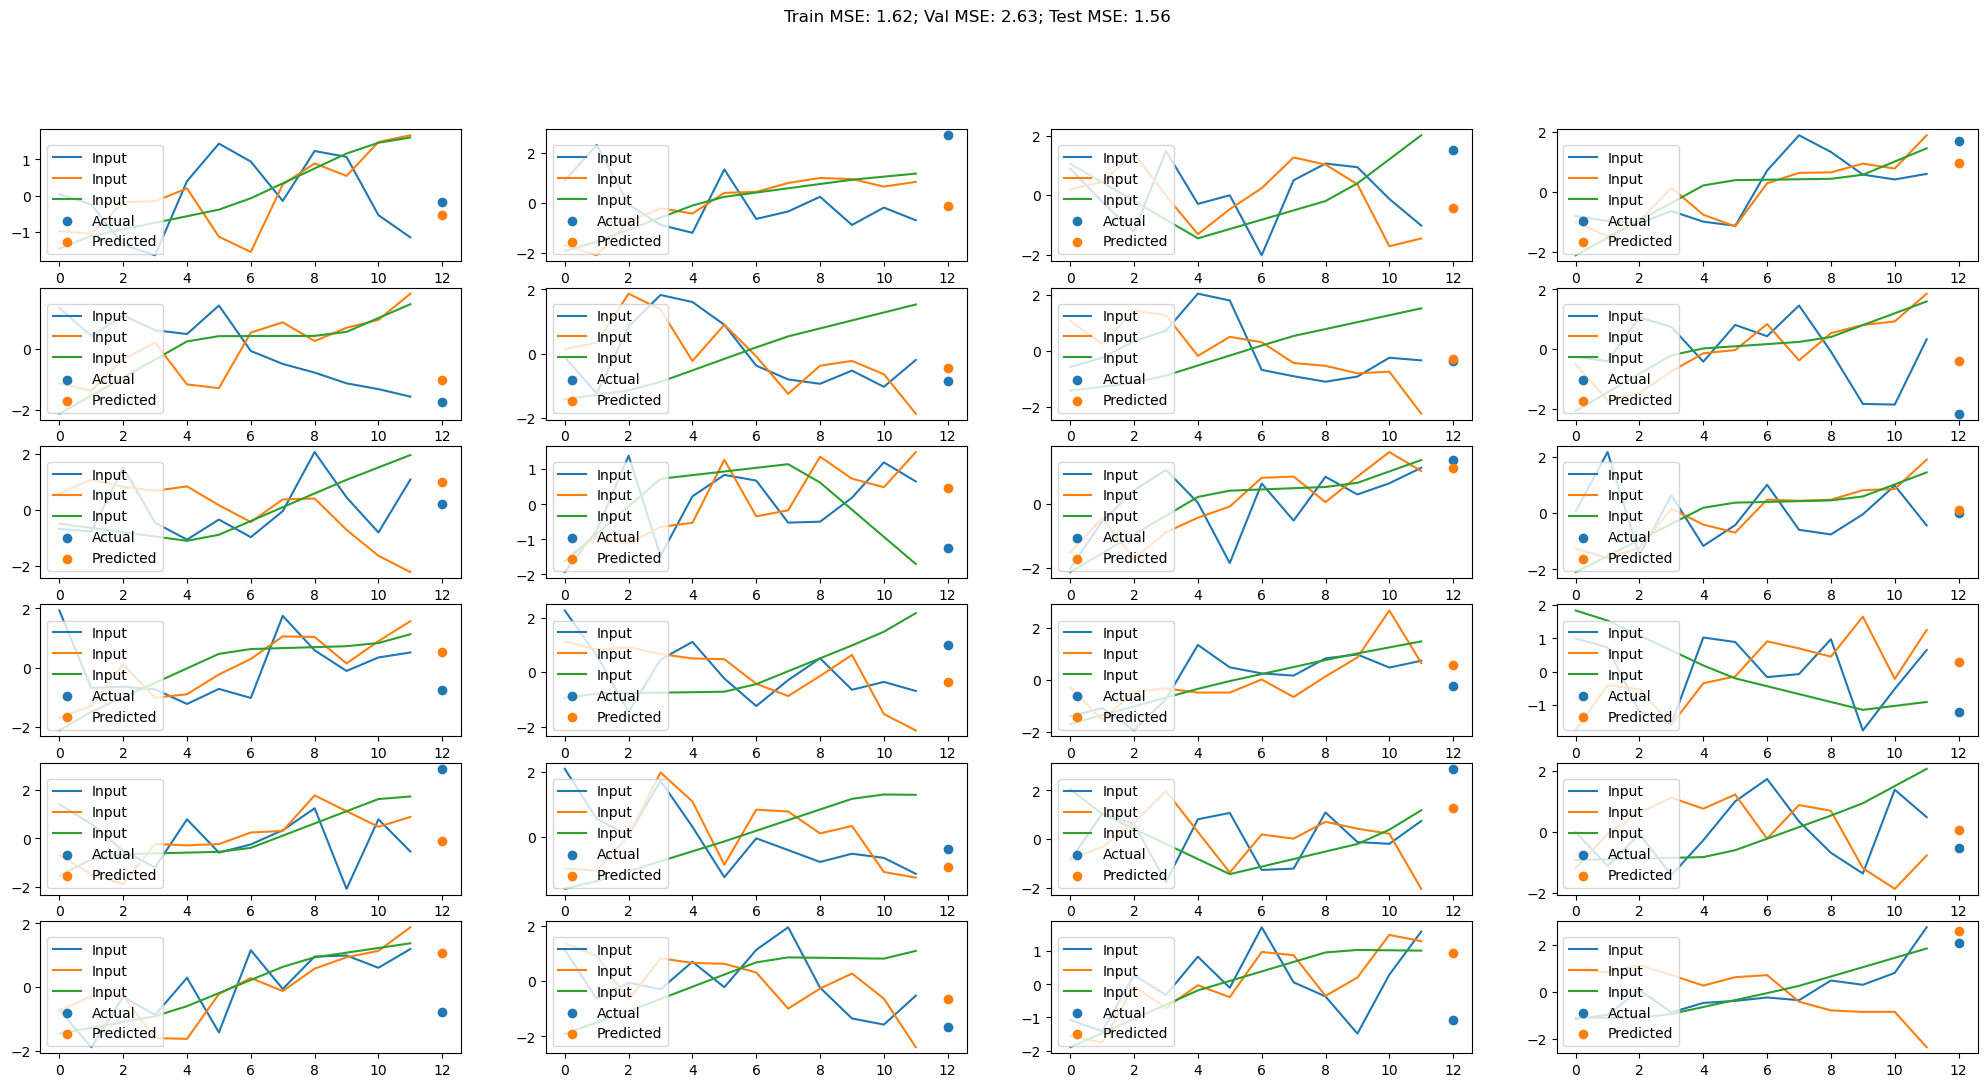

In [12]:
eval_next_element_prediction(model_lstm, [x_train_single, dept_train_single], y_train_single.reshape(-1, 1), 
                             [x_val_single, dept_val_single], y_val_single.reshape(-1, 1), 
                             [x_test_single, dept_test_single], y_test_single.reshape(-1, 1))

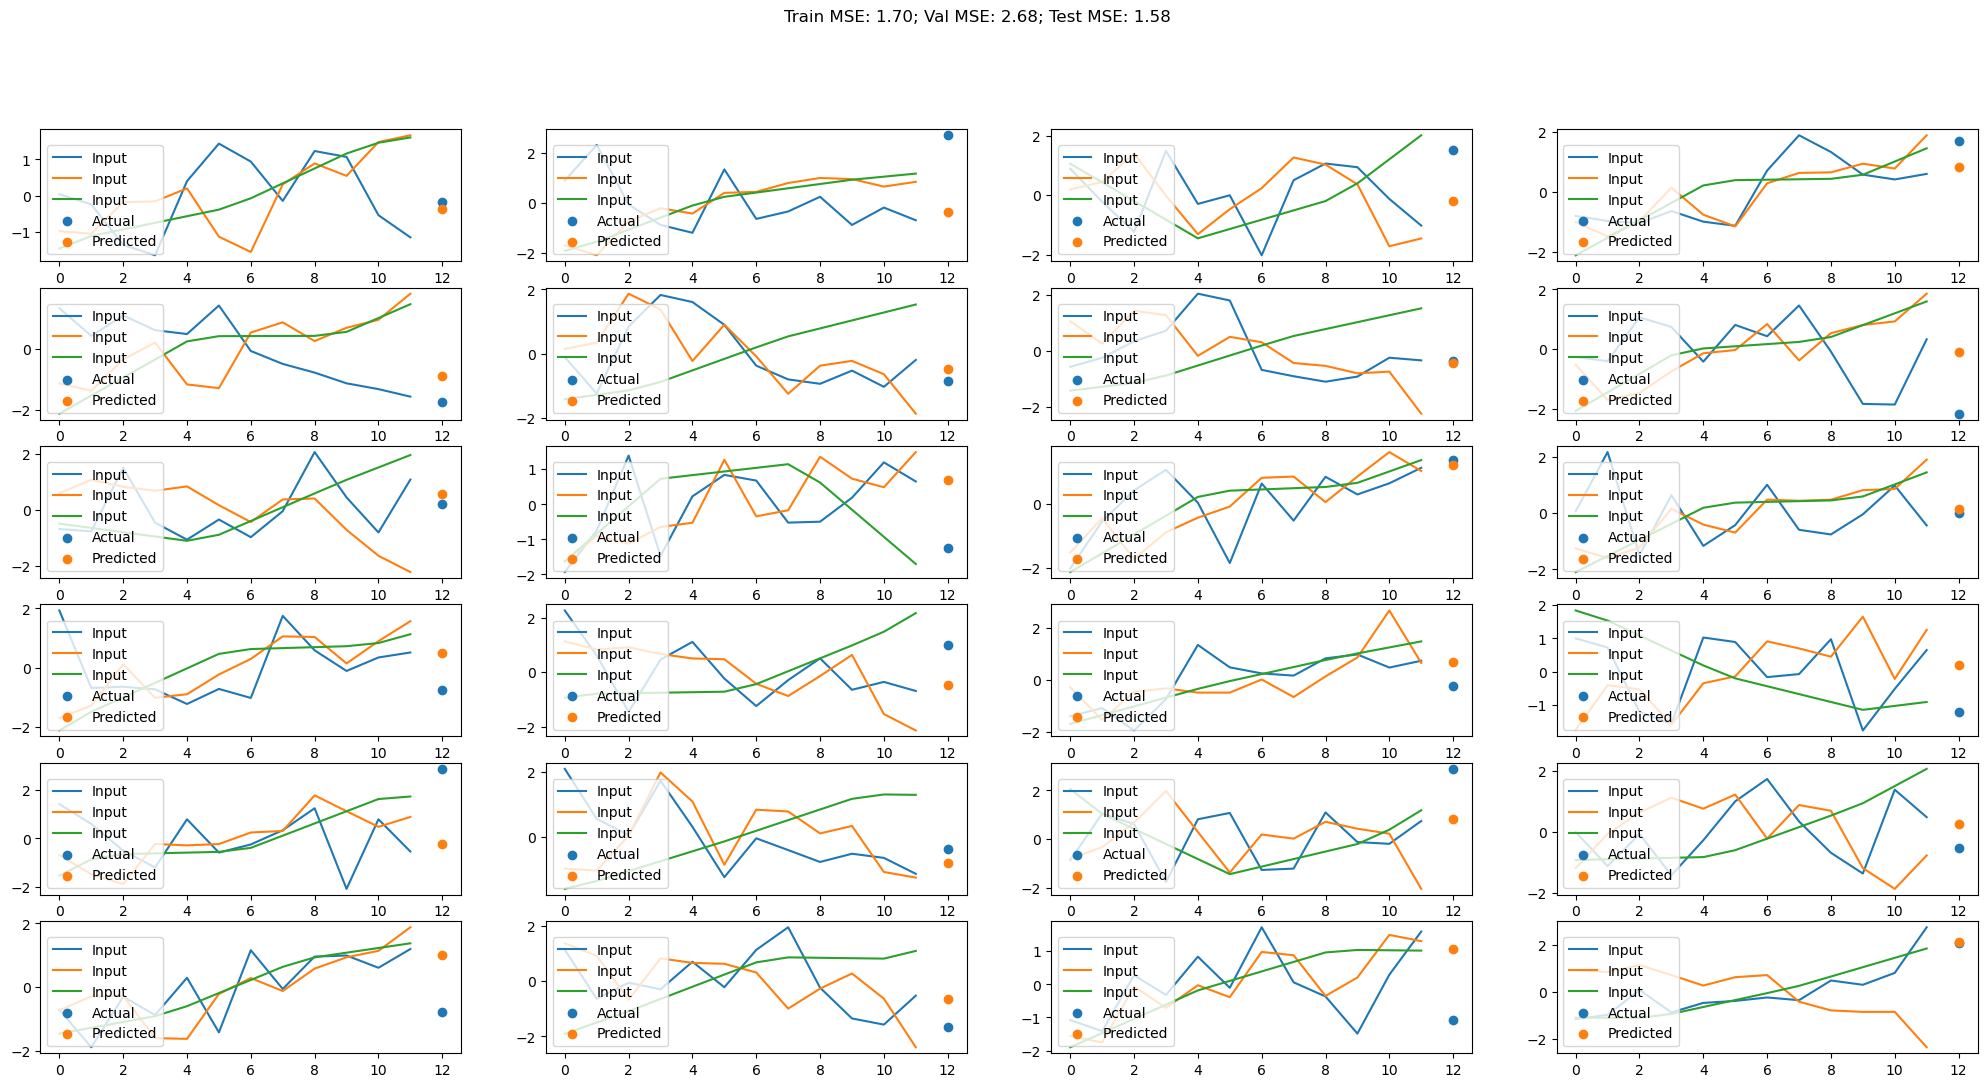

In [13]:
eval_next_element_prediction(model_bilstm, [x_train_single, dept_train_single], y_train_single.reshape(-1, 1), 
                             [x_val_single, dept_val_single], y_val_single.reshape(-1, 1), 
                             [x_test_single, dept_test_single], y_test_single.reshape(-1, 1))

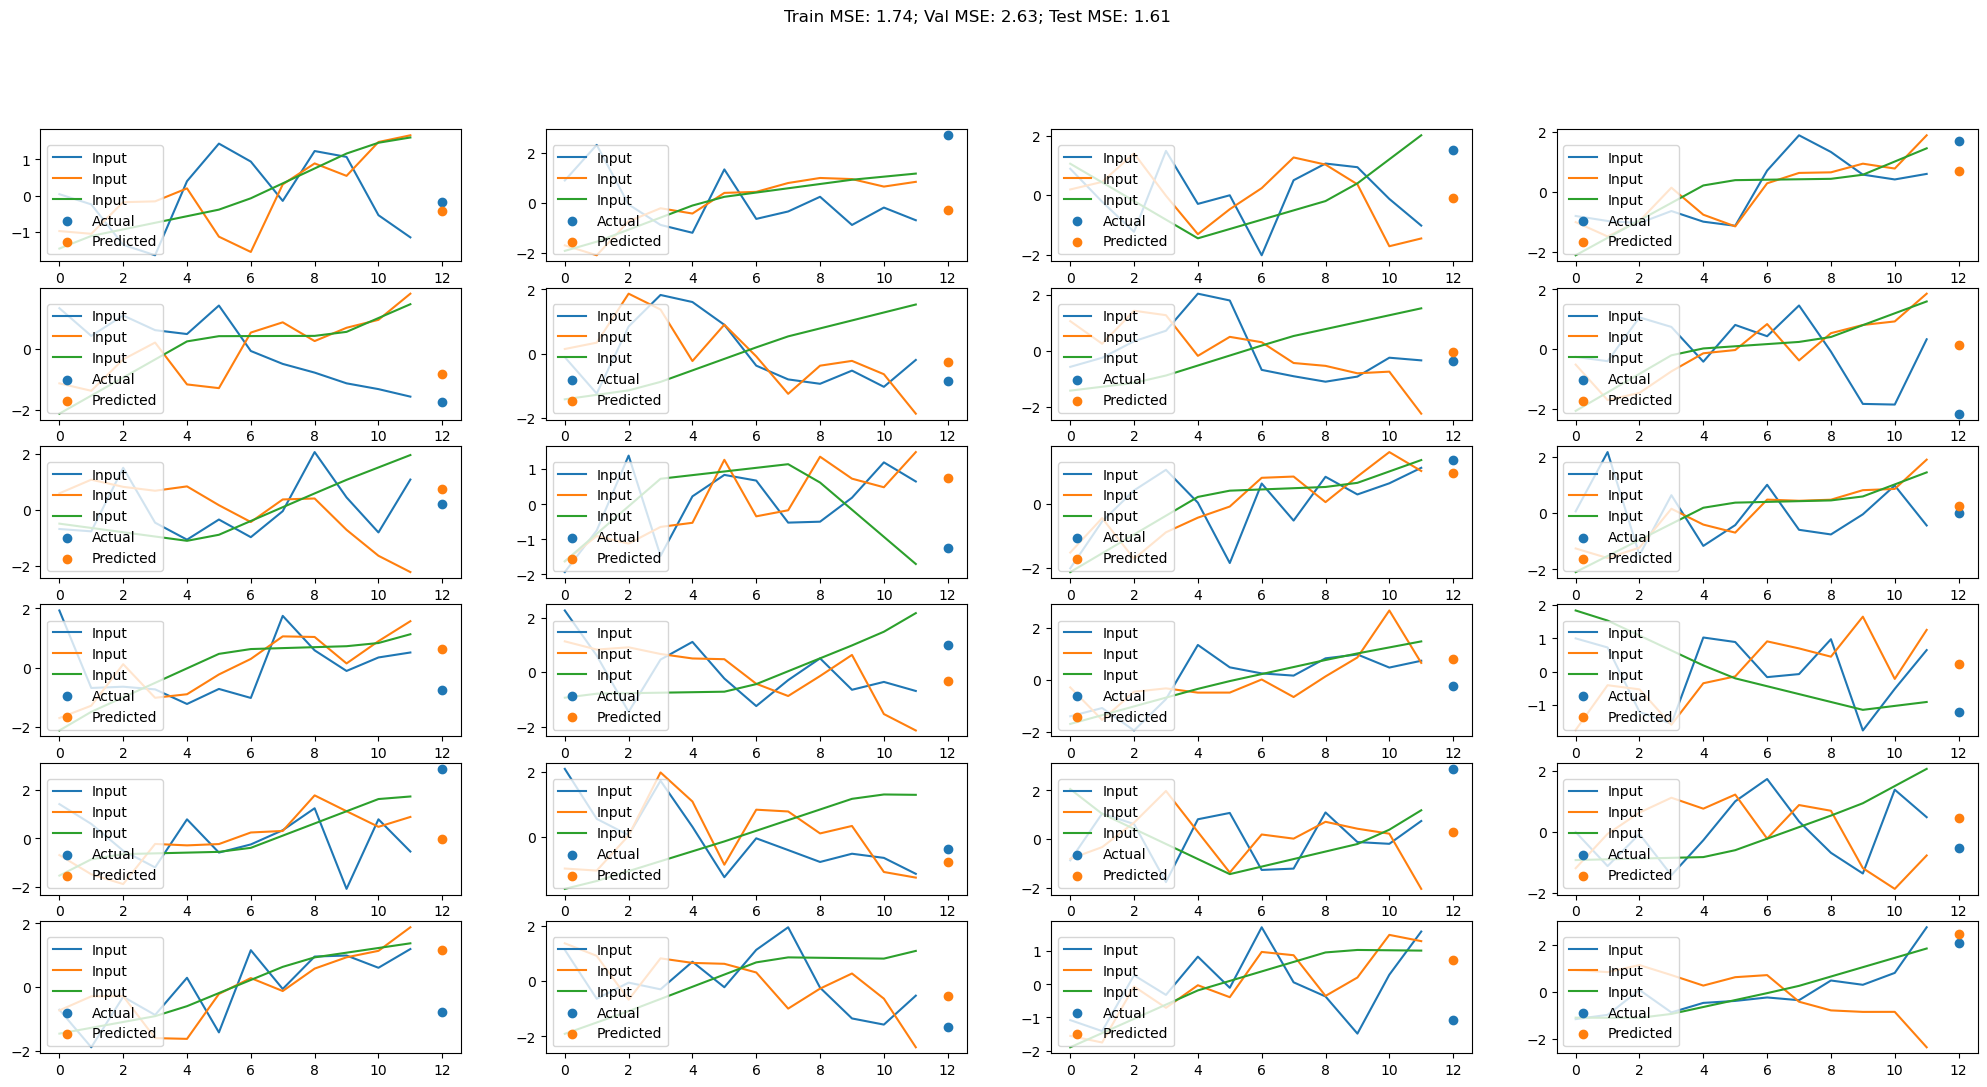

In [14]:
eval_next_element_prediction(model_bilstm_att, [x_train_single, dept_train_single], y_train_single.reshape(-1, 1), 
                             [x_val_single, dept_val_single], y_val_single.reshape(-1, 1), 
                             [x_test_single, dept_test_single], y_test_single.reshape(-1, 1))

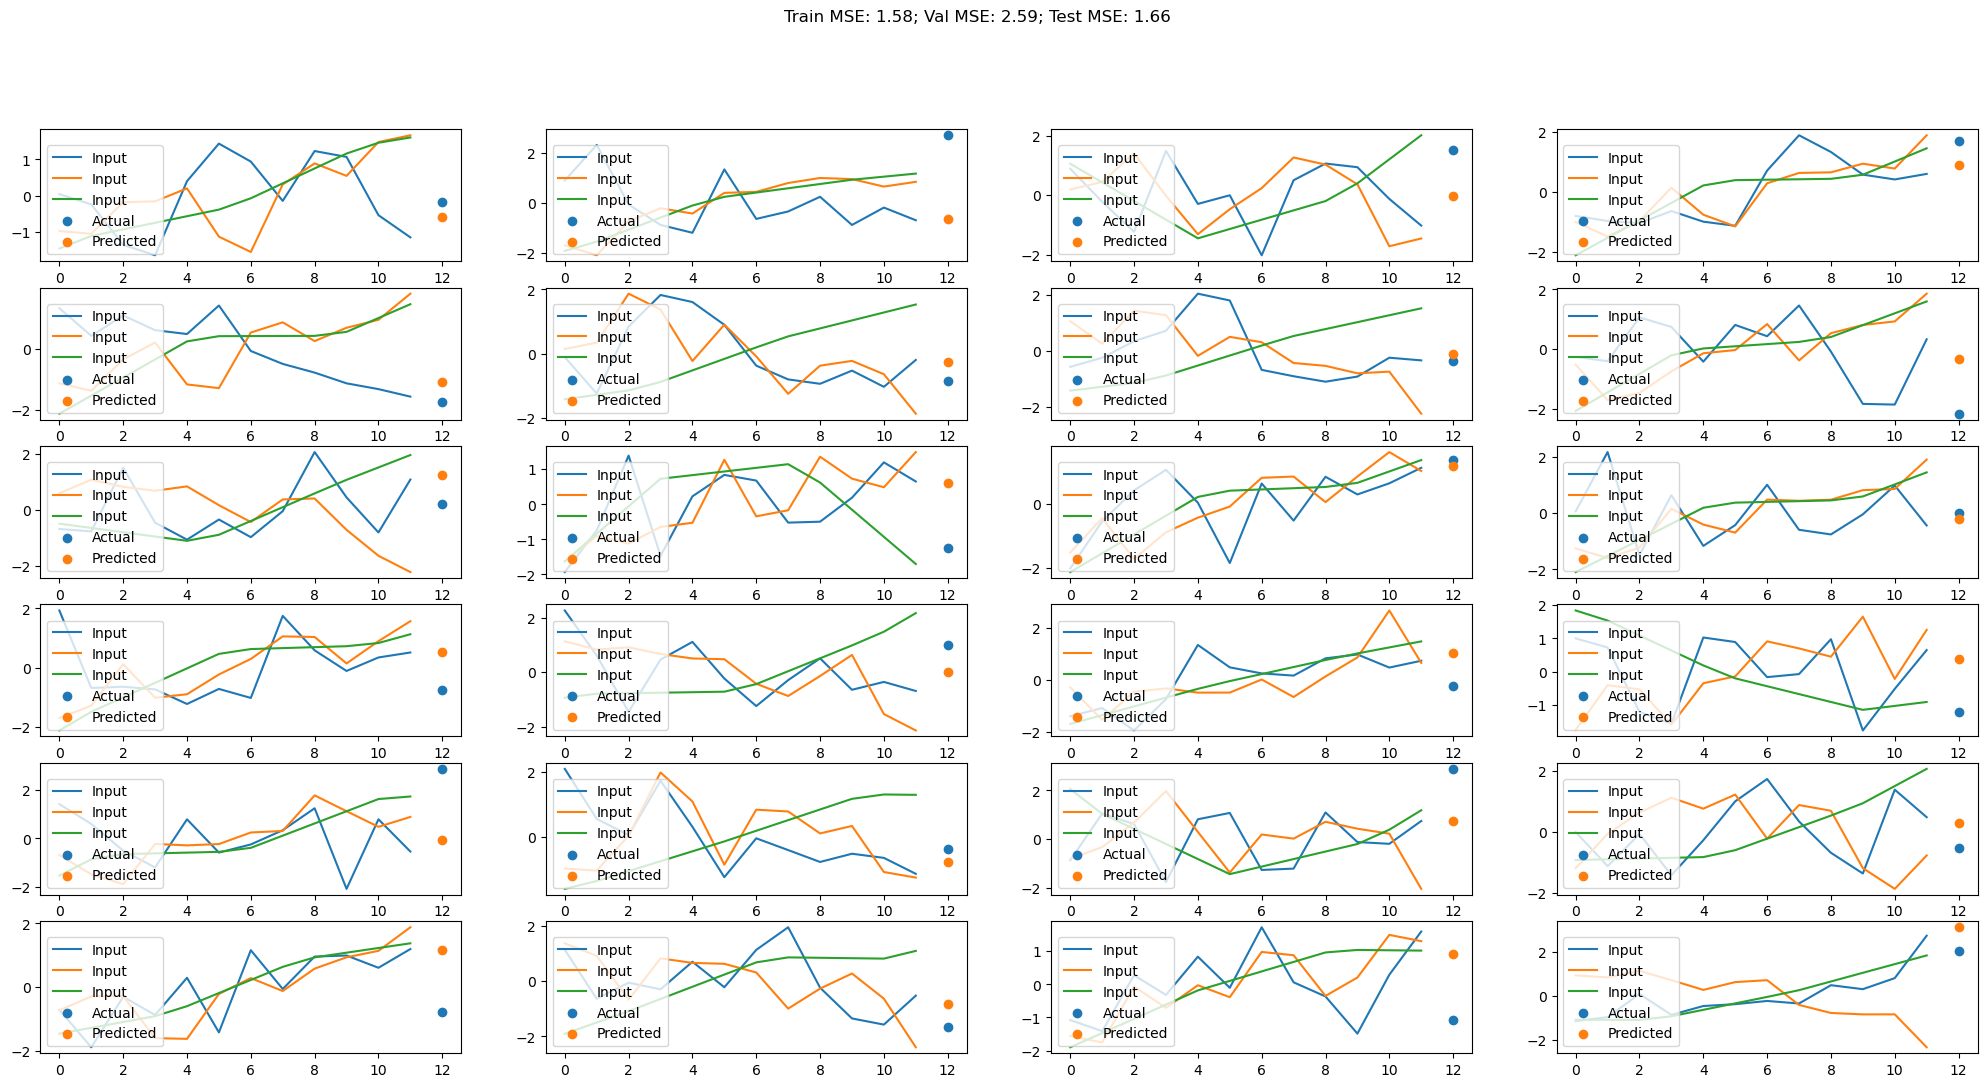

In [15]:
eval_next_element_prediction(model_transformer, [x_train_single, dept_train_single], y_train_single.reshape(-1, 1), 
                             [x_val_single, dept_val_single], y_val_single.reshape(-1, 1), 
                             [x_test_single, dept_test_single], y_test_single.reshape(-1, 1))

Results wise, we see that there are no great differences. For all models we've trained for up to 50 epochs, terminating once validation loss has not improved for 5 epochs and restoring the best weights. All models performance pretty similarly. You will see small variations in performance from one training run to the next, but genearally the LSTM will be a little worse, and the other three will be pretty similar. 

Ultimatley, when predicting the next element alone - and without incorporating a huge amount of other data - we don't get a great benefit from the larger, more complex models. One interesting consideration is the ease with which we can incorporate that extra data. I'd argue that the way we include this in the transformer is far simpler and more efficient than the approach that we use for the LSTMs. The global self-attention process of the transformer makes it very easy for us to drop this extra information in and have that propogate through the network. However, it doesn't lead to much of a performance gain here though.

## Part 2: Predicting Pedestrian Trajectories

We'll revisit the trajectory prediction from `08_Sequences/CAB420_Sequences_Example_2_Sequence_to_Sequence_Prediction.ipynb` now, but we'll add attention and transformers into the mix.

The setup here is the same as it was in the earlier example, we'll take the first 25 timesteps, and try to predict the next 25 - basically we're trying to anticipate pedestrian movement.

In [16]:
def parse_data_traj_predict(files, in_length, out_length, window_step, subsample):

    in_traj = []
    out_traj = []

    for f in files:
        data_mat = scipy.io.loadmat(f)
        k, _ = os.path.splitext(os.path.basename(f))
        data = data_mat[k][0]

        for i in range(len(data)):
            
            traj = data[i][:, 0:2].astype('float32')
            traj[:, 0] = traj[:, 0] / 640
            traj[:, 1] = traj[:, 1] / 480
                   
            startpos = 0
            endpos = in_length + out_length;
            
            while (endpos < len(traj)):
                
                traj_in = traj[startpos:startpos+in_length:subsample, :]
                traj_out = traj[startpos+in_length:endpos:subsample, :]
                            
                vel_in = numpy.sum(numpy.abs(traj_in[0, :] - traj_in[-1, :])) / len(traj_in)
                vel_out = numpy.sum(numpy.abs(traj_out[0, :] - traj_out[-1, :])) / len(traj_out)
                            
                if ((vel_in > 0.005) & (vel_out > 0.005)):
                    in_traj.append(traj_in)
                    out_traj.append(traj_out)
                
                startpos += window_step
                endpos += window_step
    
    return numpy.array(in_traj), numpy.array(out_traj)

def eval_traj_prediction(model, x_train, y_train, x_val, y_val, x_test, y_test):

    train_mse = mse(model.predict(x_train, verbose=False), y_train)
    val_mse = mse(model.predict(x_val, verbose=False), y_val)
    pred = model.predict(x_test, verbose=False)
    test_mse = mse(pred, y_test)
    
    length = x_test.shape[1]
    fig = plt.figure(figsize=[30, 20])
    samples_to_plot = numpy.linspace(0,len(y_test)-1,24).astype('int')
    for i,idx in enumerate(samples_to_plot):
        ax = fig.add_subplot(6, 4, i+1)    
        ax.plot(x_test[idx,:,0], x_test[idx,:,1], 'b', label='Input')
        ax.plot(y_test[idx,:,0], y_test[idx,:,1], 'g', label = 'Actual')
        ax.plot(pred[idx,:,0], pred[idx,:,1], 'r', label = 'Predicted')
        ax.legend(loc='lower left');
    fig.suptitle('Train MSE: %1.4f; Val MSE: %1.4f; Test MSE: %1.4f' % (train_mse, val_mse, test_mse))

files = sorted(glob.glob('../data/EIF/*.mat'))
num_train_files = int(len(files)*0.6)
num_val_files = int(len(files)*0.2)

train_files = files[0:num_train_files]
val_files = files[num_train_files:num_train_files + num_val_files]
test_files = files[num_train_files + num_val_files:]

x_train_seq, y_train_seq = parse_data_traj_predict(train_files, 50, 50, 2, 2)
x_val_seq, y_val_seq = parse_data_traj_predict(val_files, 50, 50, 2, 2)
x_test_seq, y_test_seq = parse_data_traj_predict(test_files, 50, 50, 2, 2)

Model wise, we'll use the same four models that we used above, creating them using the same functions. There are however three key differences between what we had above and what we have here:
* Our outputs are now sequences, so all of our models have been changed to be sequence-to-sequence models. For the LSTMs this means that the output of our second LSTM is switched to being a sequence; for the transformers it effectivley changes nothing. For all, it means that we're now applying a dense layer operation to all embeddings in the sequence to get the output at each timestamp.
* We don't have a second input. If we had data on the time of day, we could add that as an additional piece of information, but sadly the timestep information that we have does not actually capture that, so we'll just the single input.
* All the embeddings are bigger. I've simply doubled what they were before. They could probably afford to go bigger again, but I want to avoid these getting too big to avoid training times getting too long. I've also doubled the number of attention heads in the transformer.

In [17]:
model_lstm = lstm(25, 2, 25, 2, 128, False, None)
model_lstm, history = train_model(model_lstm, x_train_seq, y_train_seq, x_val_seq, y_val_seq, False)

In [18]:
model_bilstm = bidirectional_lstm(25, 2, 25, 2, 128, False, None)
model_bilstm, history = train_model(model_bilstm, x_train_seq, y_train_seq, x_val_seq, y_val_seq, False)

In [19]:
model_bilstm_att = bidirectional_lstm_with_attention(25, 2, 25, 2, 128, False, None)
model_bilstm_att, history = train_model(model_bilstm_att, x_train_seq, y_train_seq, x_val_seq, y_val_seq, False)

In [20]:
model_transformer = transformer(25, 2, 25, 2, 256, 4, 128, False, None)
model_transformer, history = train_model(model_transformer, x_train_seq, y_train_seq, x_val_seq, y_val_seq, False)

Model complexity is pretty much identical to what we had above. We're not visualising the number of parameters here, but if you wanted to you'd see more of the less the same numbers - and certainly the same trends across the models.

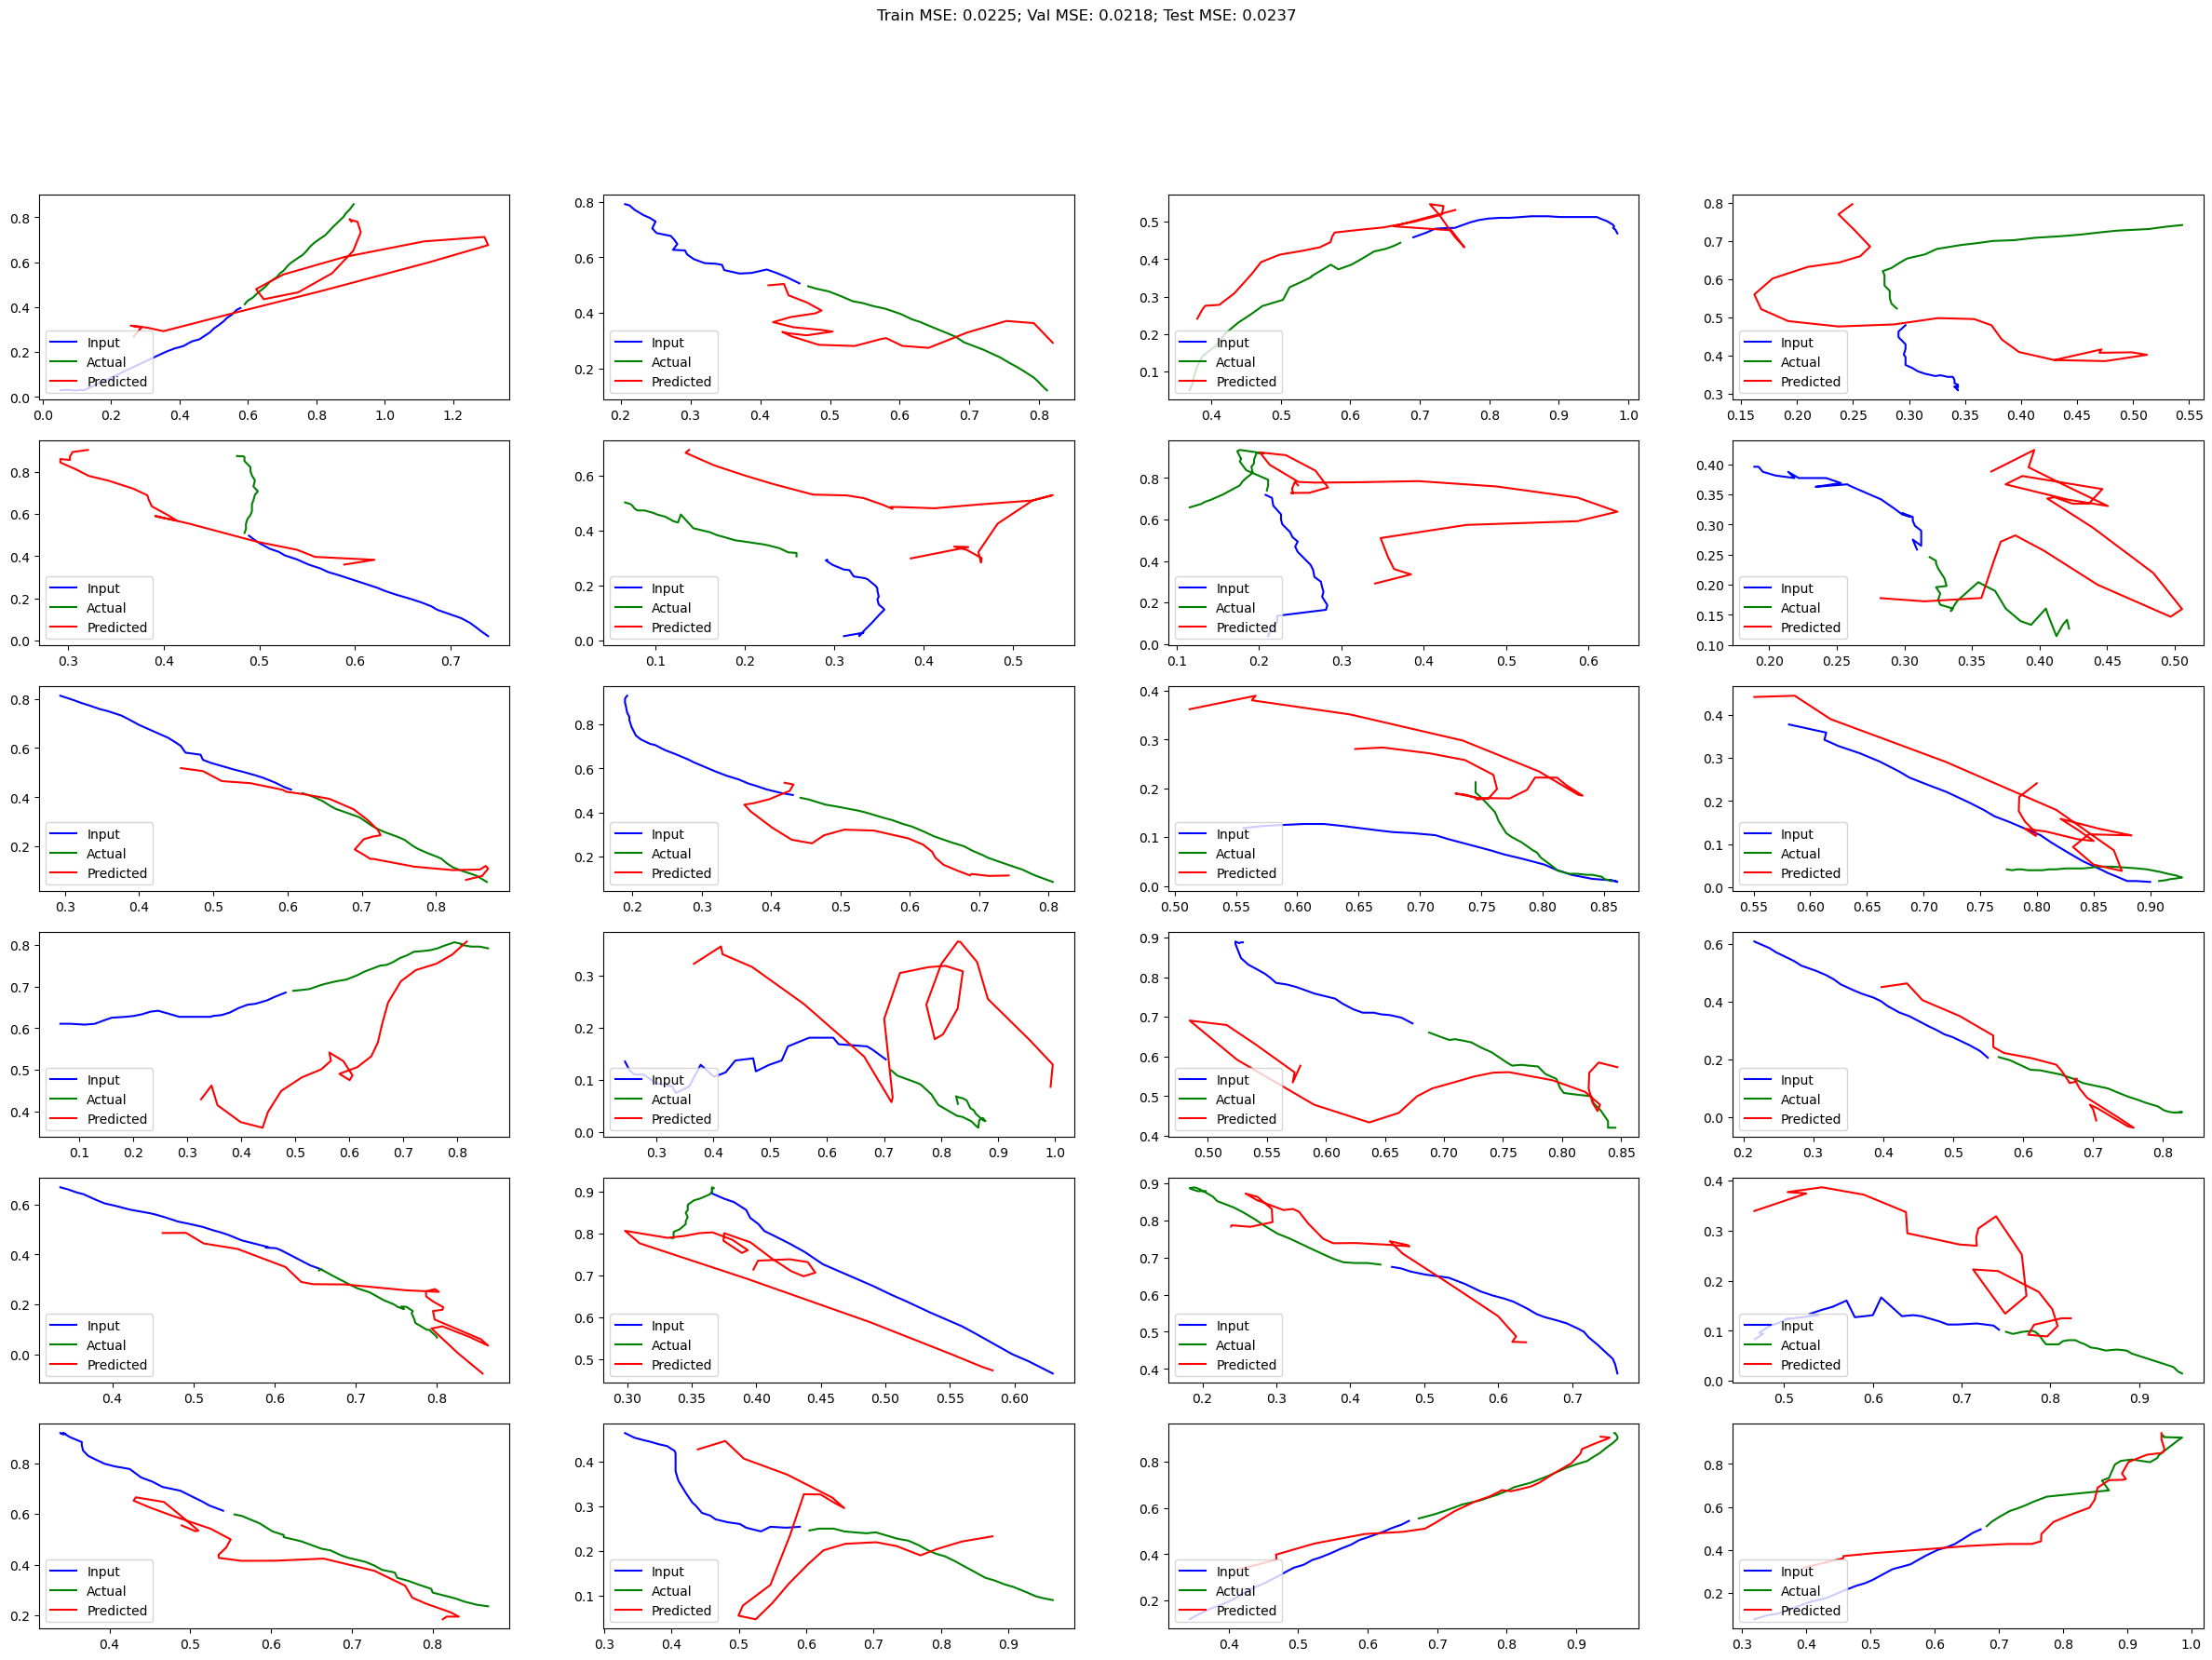

In [21]:
eval_traj_prediction(model_lstm, x_train_seq, y_train_seq, x_val_seq, y_val_seq, x_test_seq, y_test_seq)

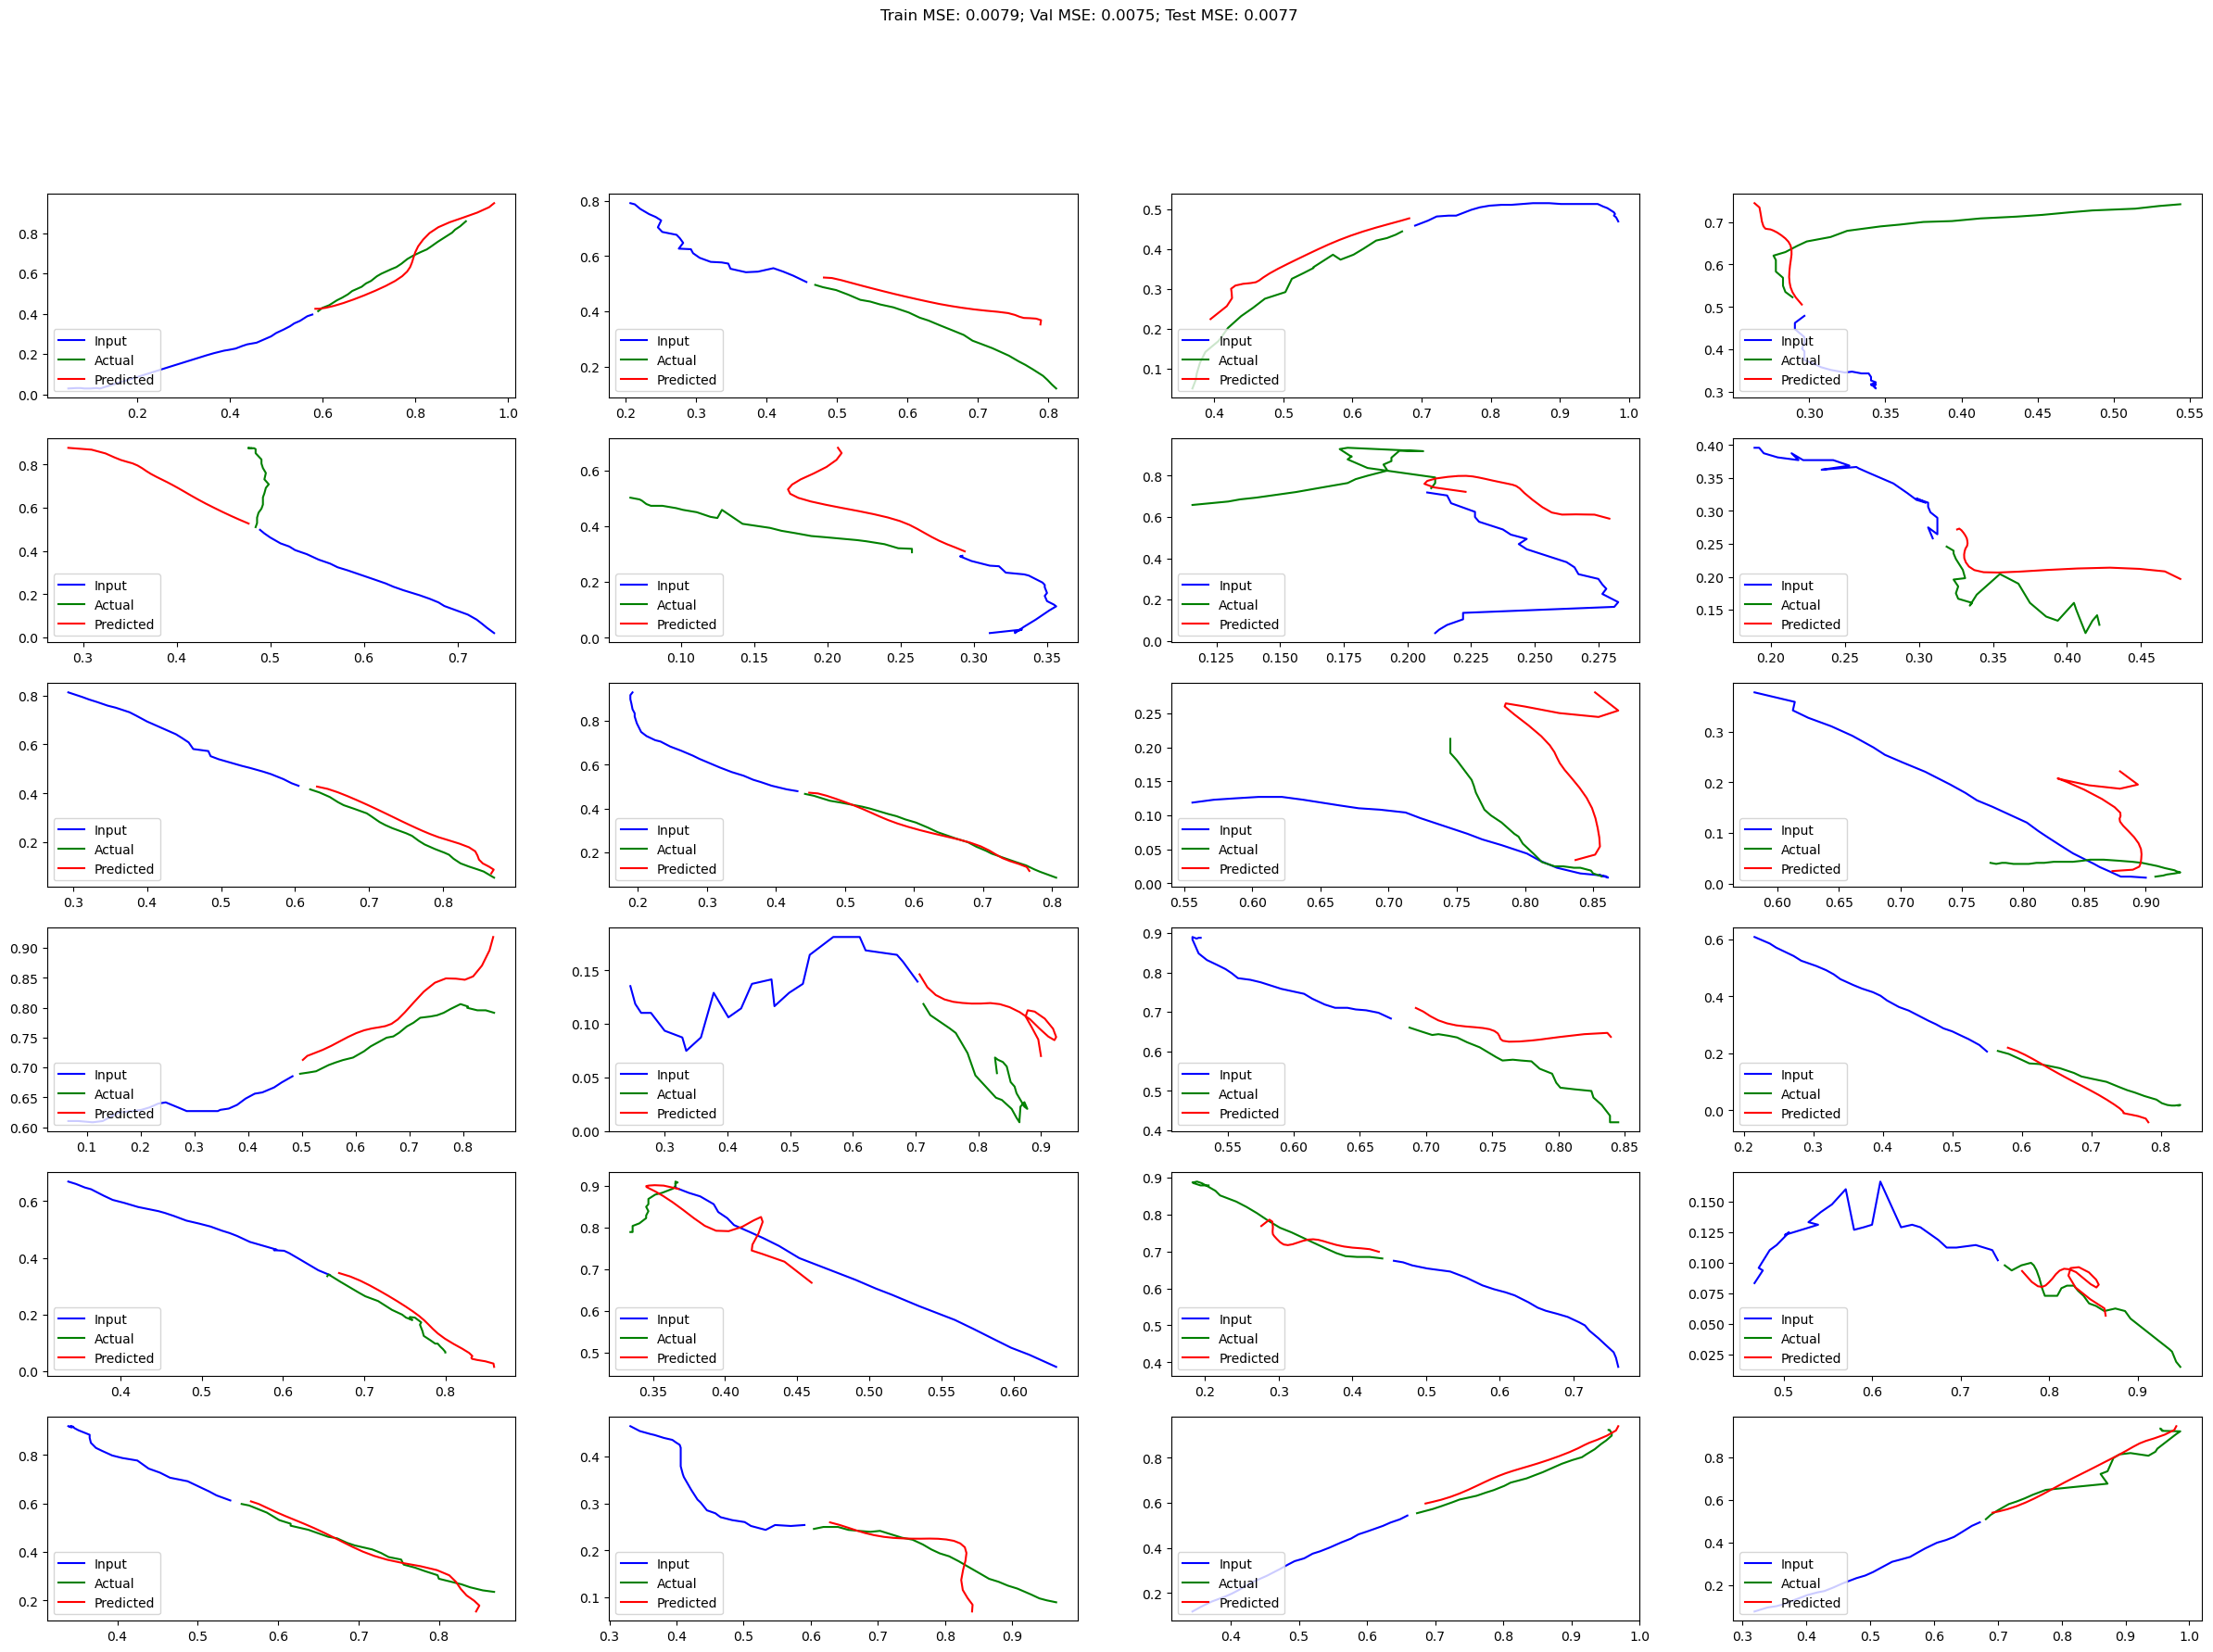

In [22]:
eval_traj_prediction(model_bilstm, x_train_seq, y_train_seq, x_val_seq, y_val_seq, x_test_seq, y_test_seq)

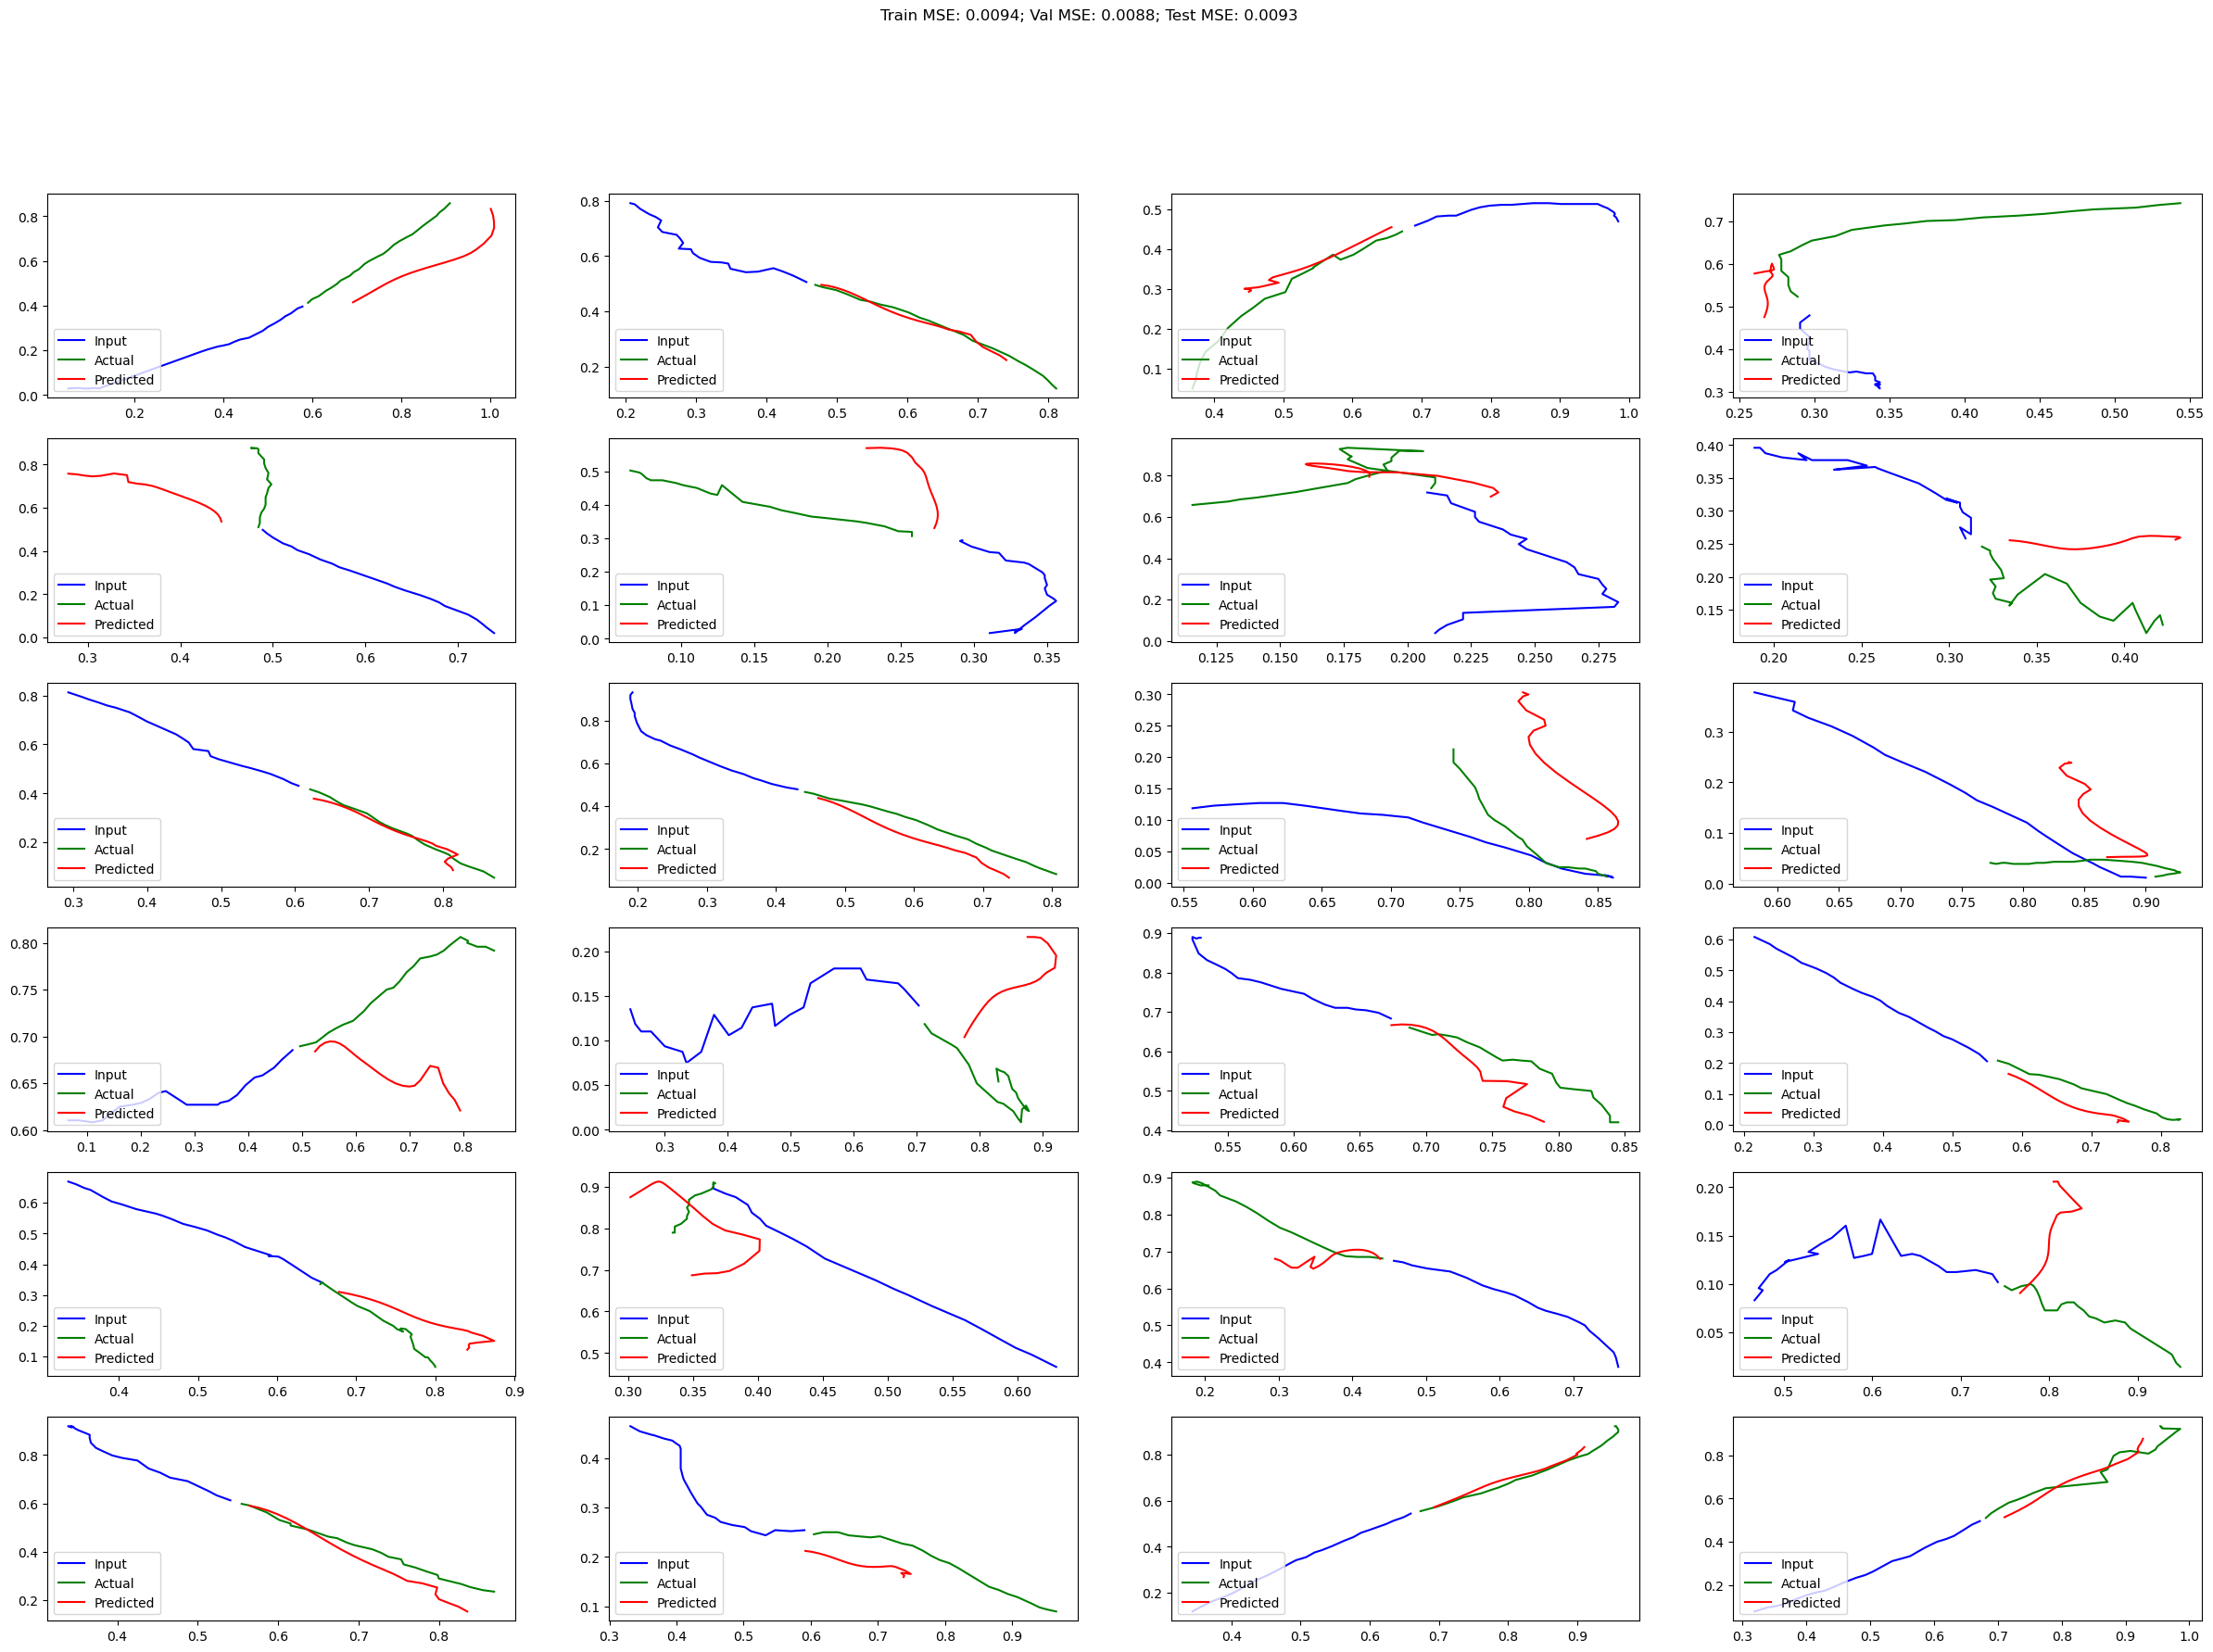

In [23]:
eval_traj_prediction(model_bilstm_att, x_train_seq, y_train_seq, x_val_seq, y_val_seq, x_test_seq, y_test_seq)

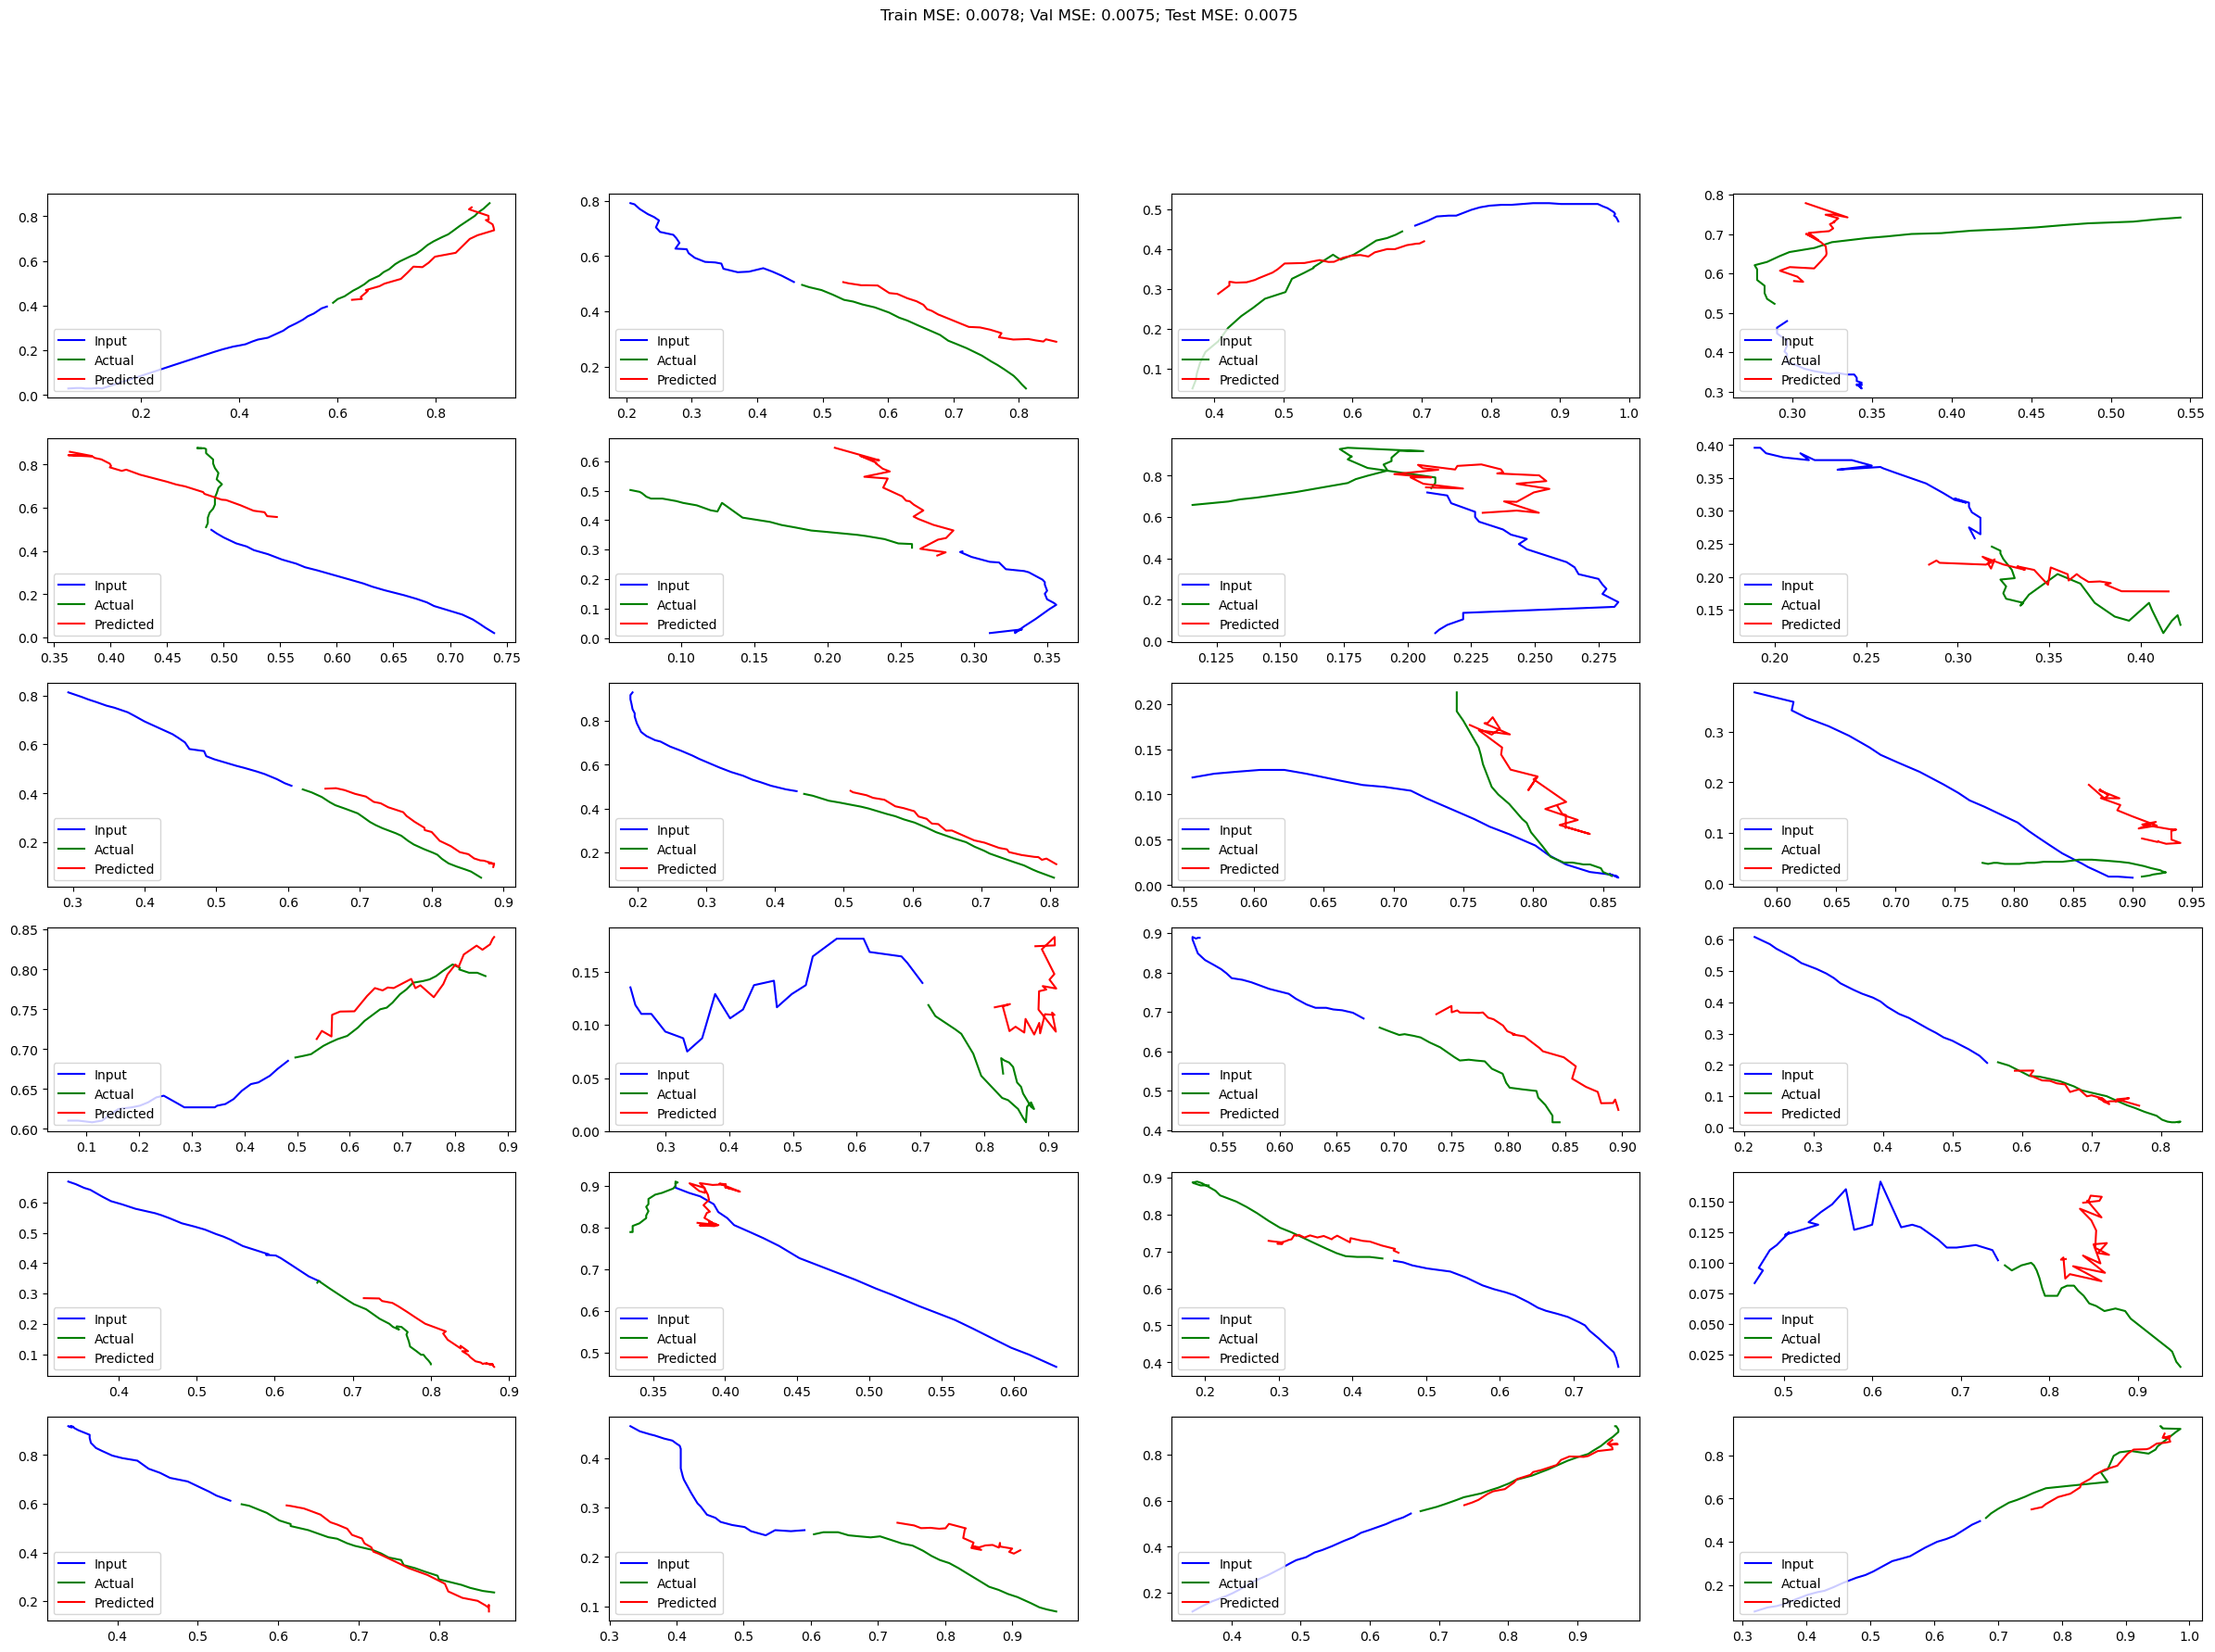

In [24]:
eval_traj_prediction(model_transformer, x_train_seq, y_train_seq, x_val_seq, y_val_seq, x_test_seq, y_test_seq)

Comparing the performance of our models, we see the following:
* The LSTM is not very good. Using only unidirectional processing through the LSTM means we struggle to capture the path in the data, and so our prediction is pretty wild and not very accurate.
* Adding the bidirectional LSTM leads to a huge improvement. Predictions generally become more plausible, and predicted paths flow more naturally from the observed trajectory.
* Adding the attention mechanism makes another small improvement. Interestingly this may or may not lead to an improvement in MSE (this will vary from one training run to the next), but generally predicted trajectories look a bit more plausible, with fewer wierd and wild deviations.
* The transformer leads to the best performance of the lot (in most test runs anyway), and predicted trajectories contain more high frequency information/variation than the LSTMs which tend to produce very smooth plots. While in many cases predictions are quite good, there are perhaps more really very clearly wrong cases with the transformer than we see with the attention based LSTM model. In particular, we see some cases where some seemingly impossibly jagged trajectories are created, with paths zig-zagging back and forth.

Because we can, we'll now see what happens when we make the sequenecs twice as long. To do this, all we'll do is remove the decimation we had in the sequences. Previously we've been taking only every second position, we'll just take every position, and then modify the input size (and output size) of our networks accordingly.

In [25]:
x_train_seq, y_train_seq = parse_data_traj_predict(train_files, 50, 50, 1, 1)
x_val_seq, y_val_seq = parse_data_traj_predict(val_files, 50, 50, 1, 1)
x_test_seq, y_test_seq = parse_data_traj_predict(test_files, 50, 50, 1, 1)

In [26]:
model_lstm = lstm(50, 2, 50, 2, 128, False, None)
model_lstm, history = train_model(model_lstm, x_train_seq, y_train_seq, x_val_seq, y_val_seq, False)
model_bilstm = bidirectional_lstm(50, 2, 50, 2, 128, False, None)
model_bilstm, history = train_model(model_bilstm, x_train_seq, y_train_seq, x_val_seq, y_val_seq, False)
model_bilstm_att = bidirectional_lstm_with_attention(50, 2, 50, 2, 128, False, None)
model_bilstm_att, history = train_model(model_bilstm_att, x_train_seq, y_train_seq, x_val_seq, y_val_seq, False)
model_transformer = transformer(50, 2, 50, 2, 256, 4, 128, False, None)
model_transformer, history = train_model(model_transformer, x_train_seq, y_train_seq, x_val_seq, y_val_seq, False)

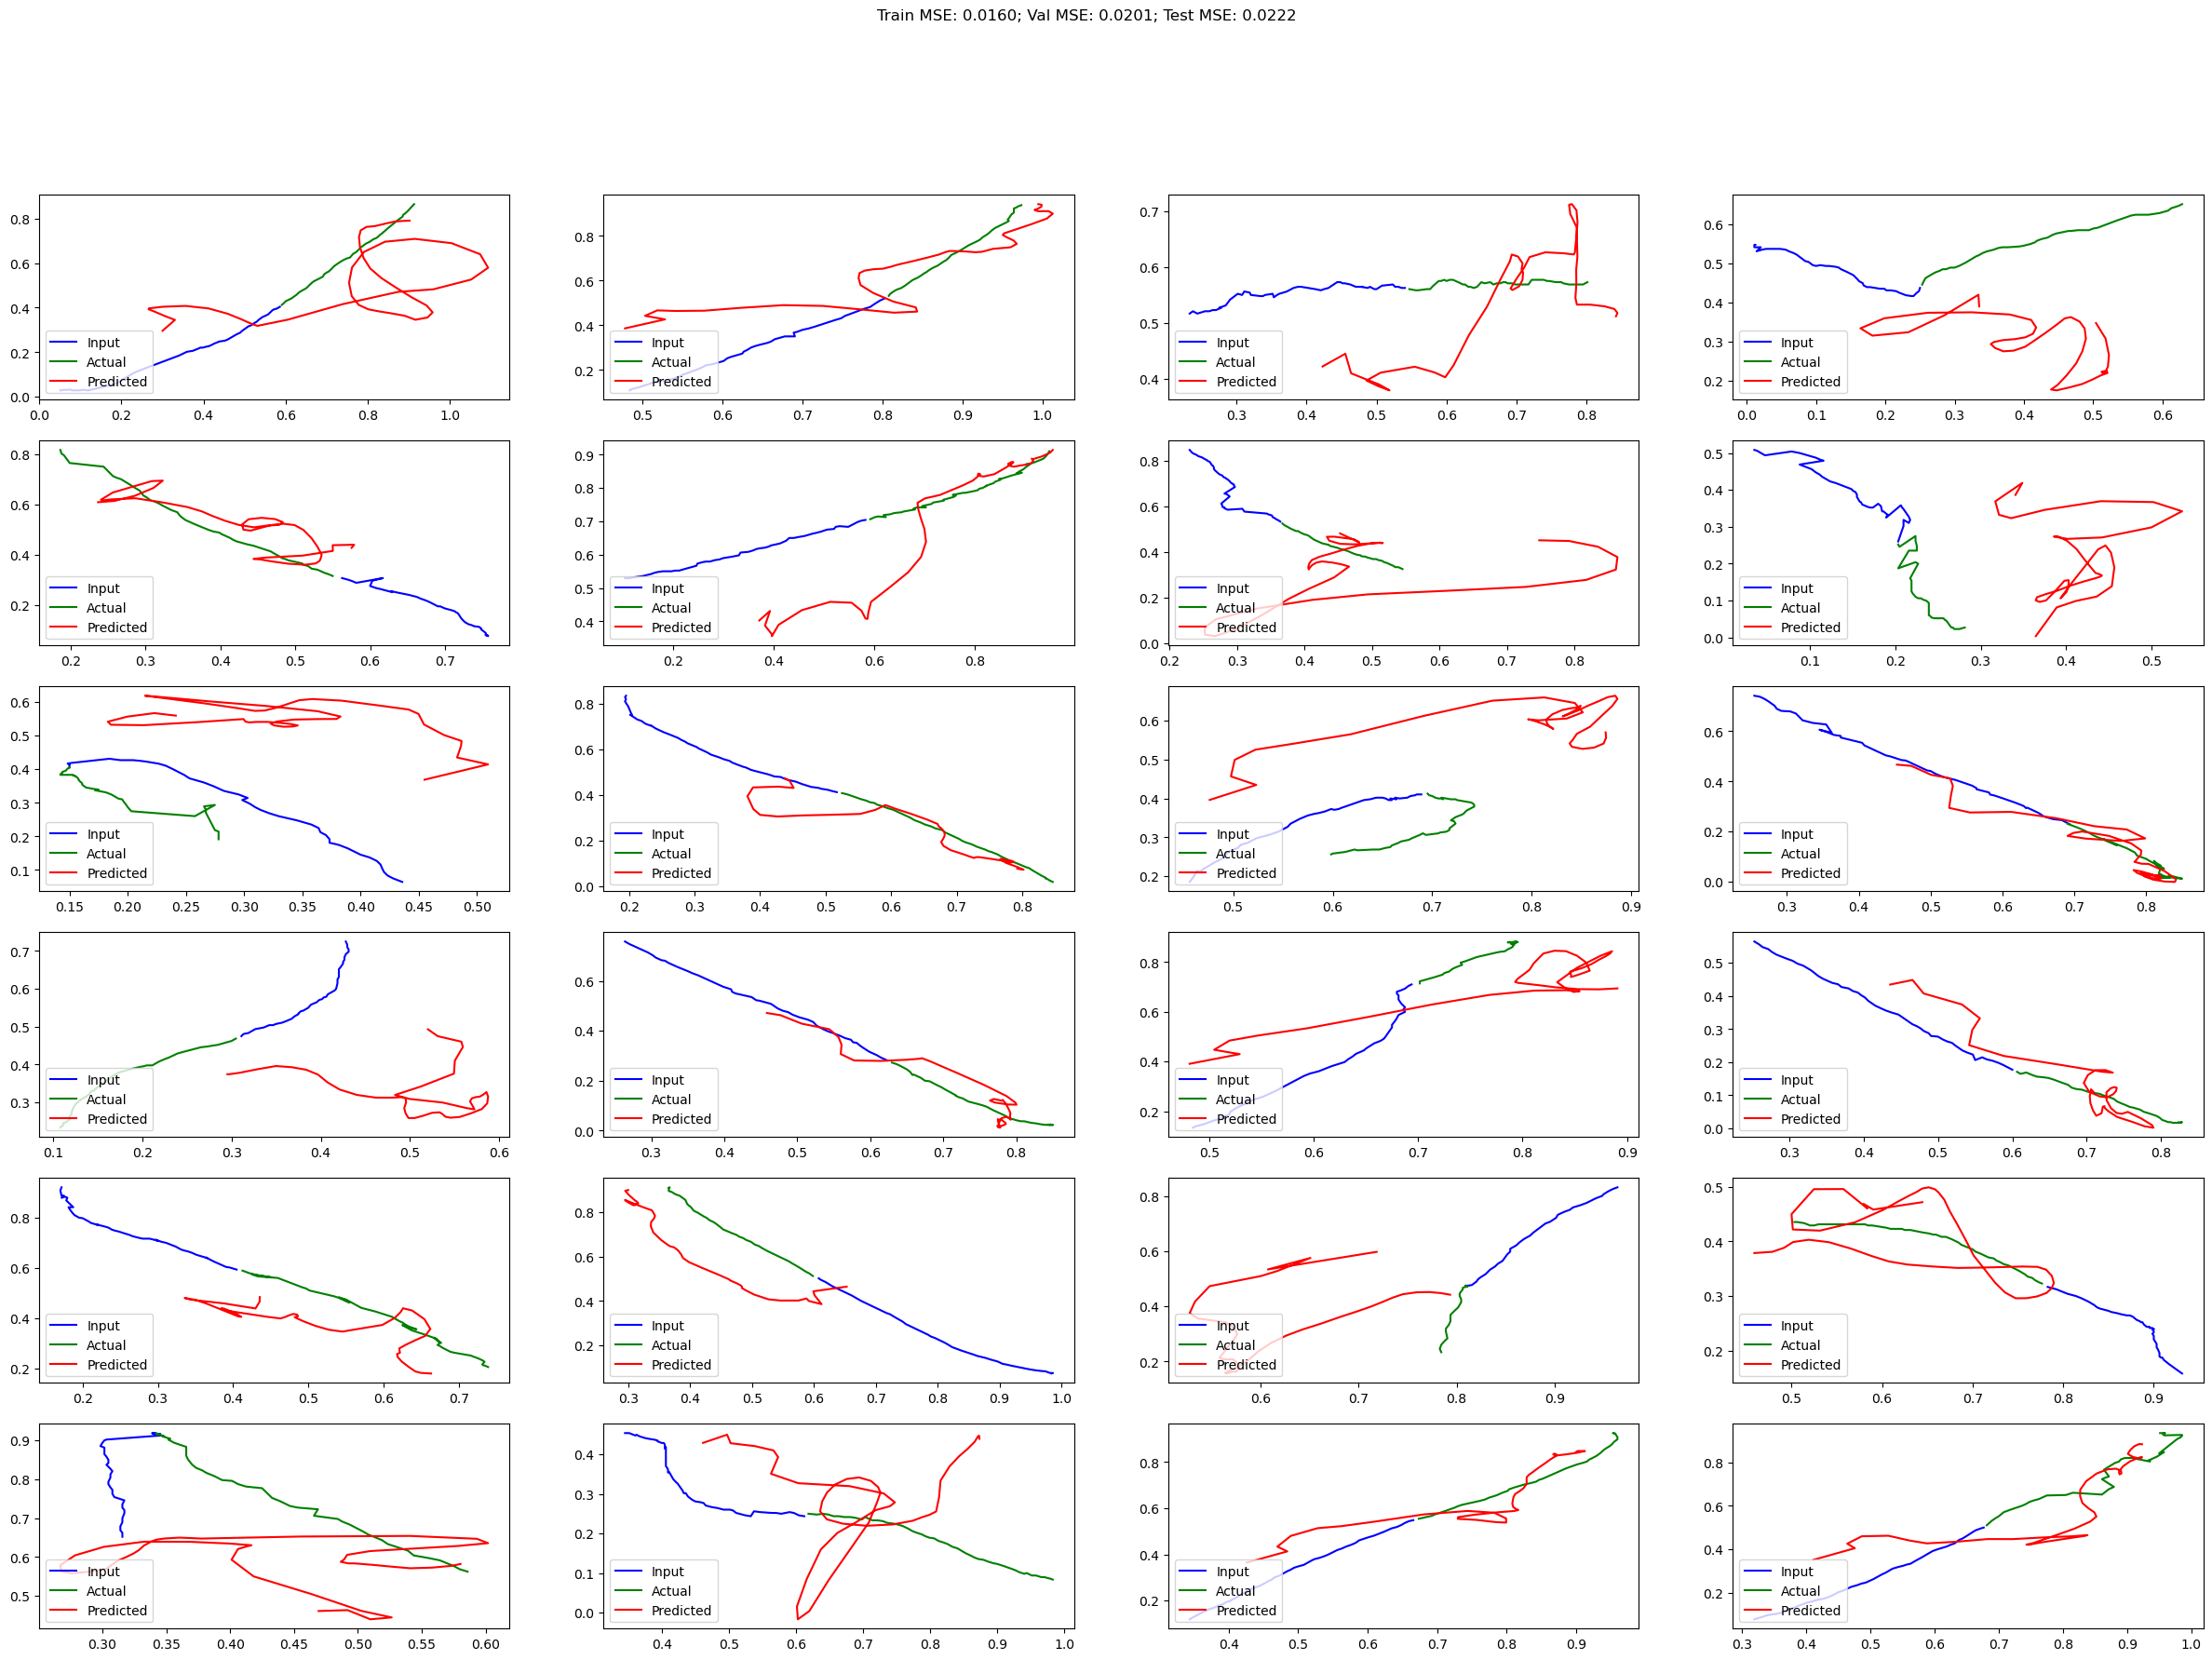

In [27]:
eval_traj_prediction(model_lstm, x_train_seq, y_train_seq, x_val_seq, y_val_seq, x_test_seq, y_test_seq)

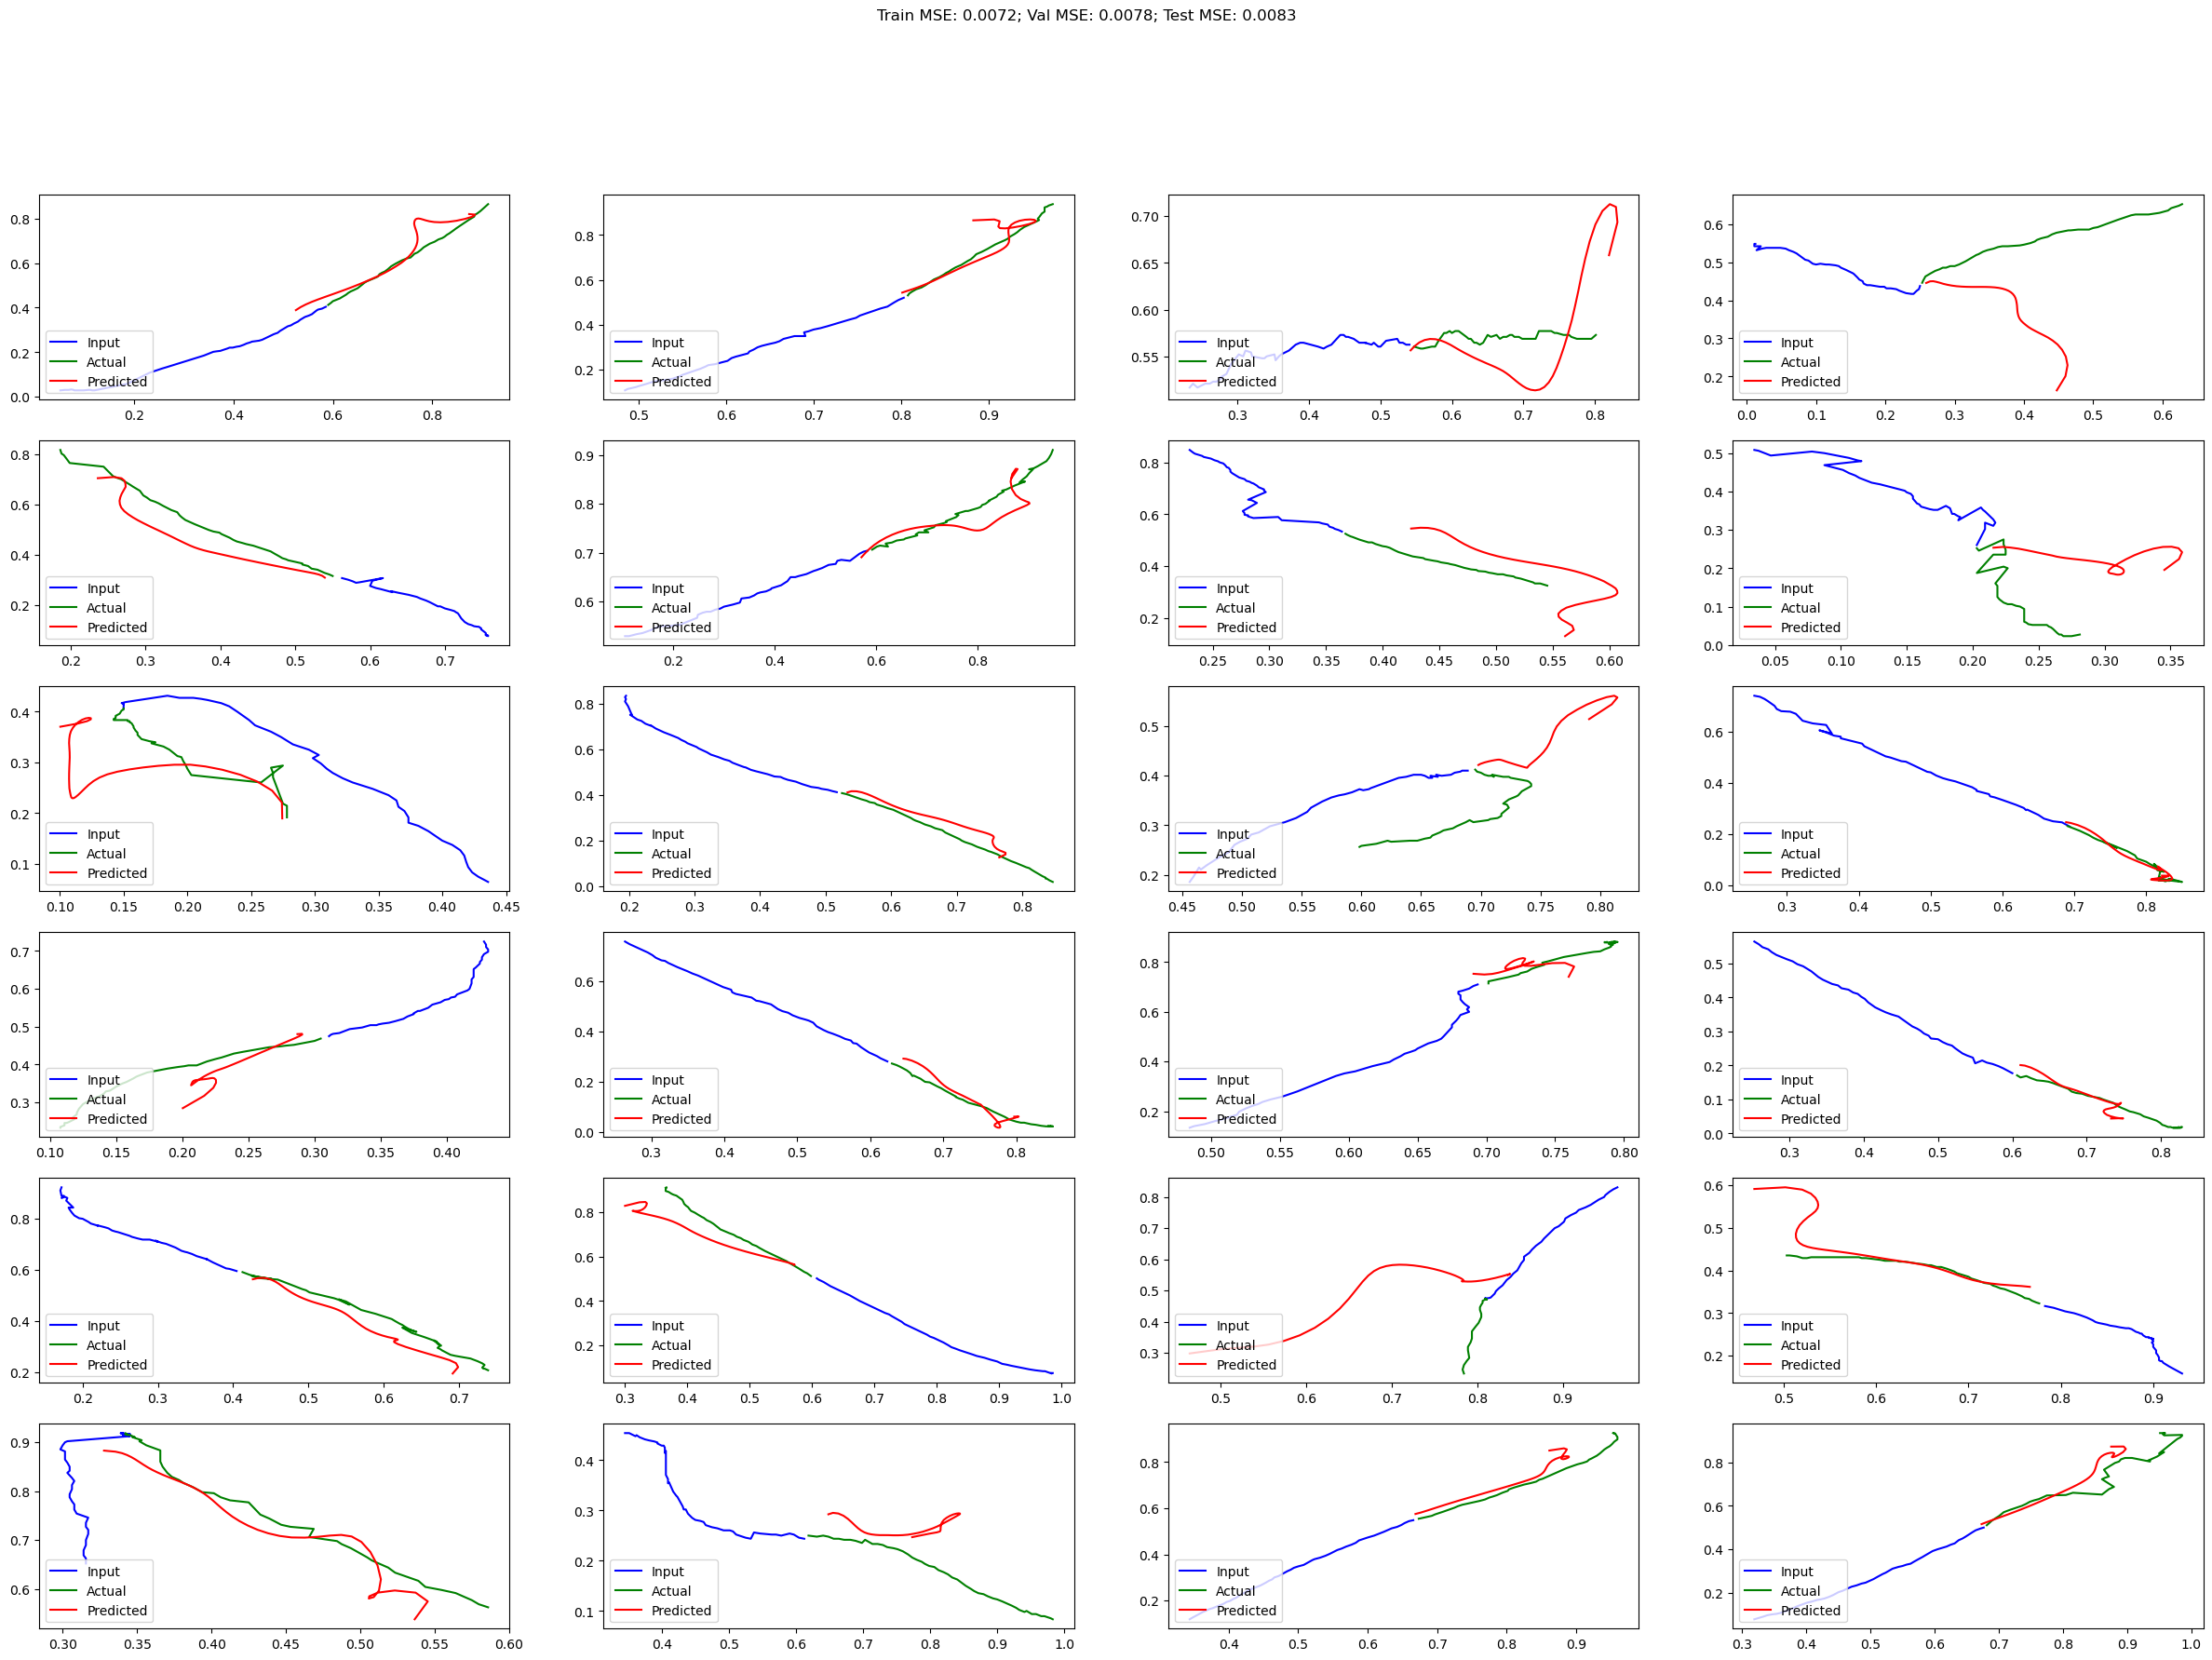

In [28]:
eval_traj_prediction(model_bilstm, x_train_seq, y_train_seq, x_val_seq, y_val_seq, x_test_seq, y_test_seq)

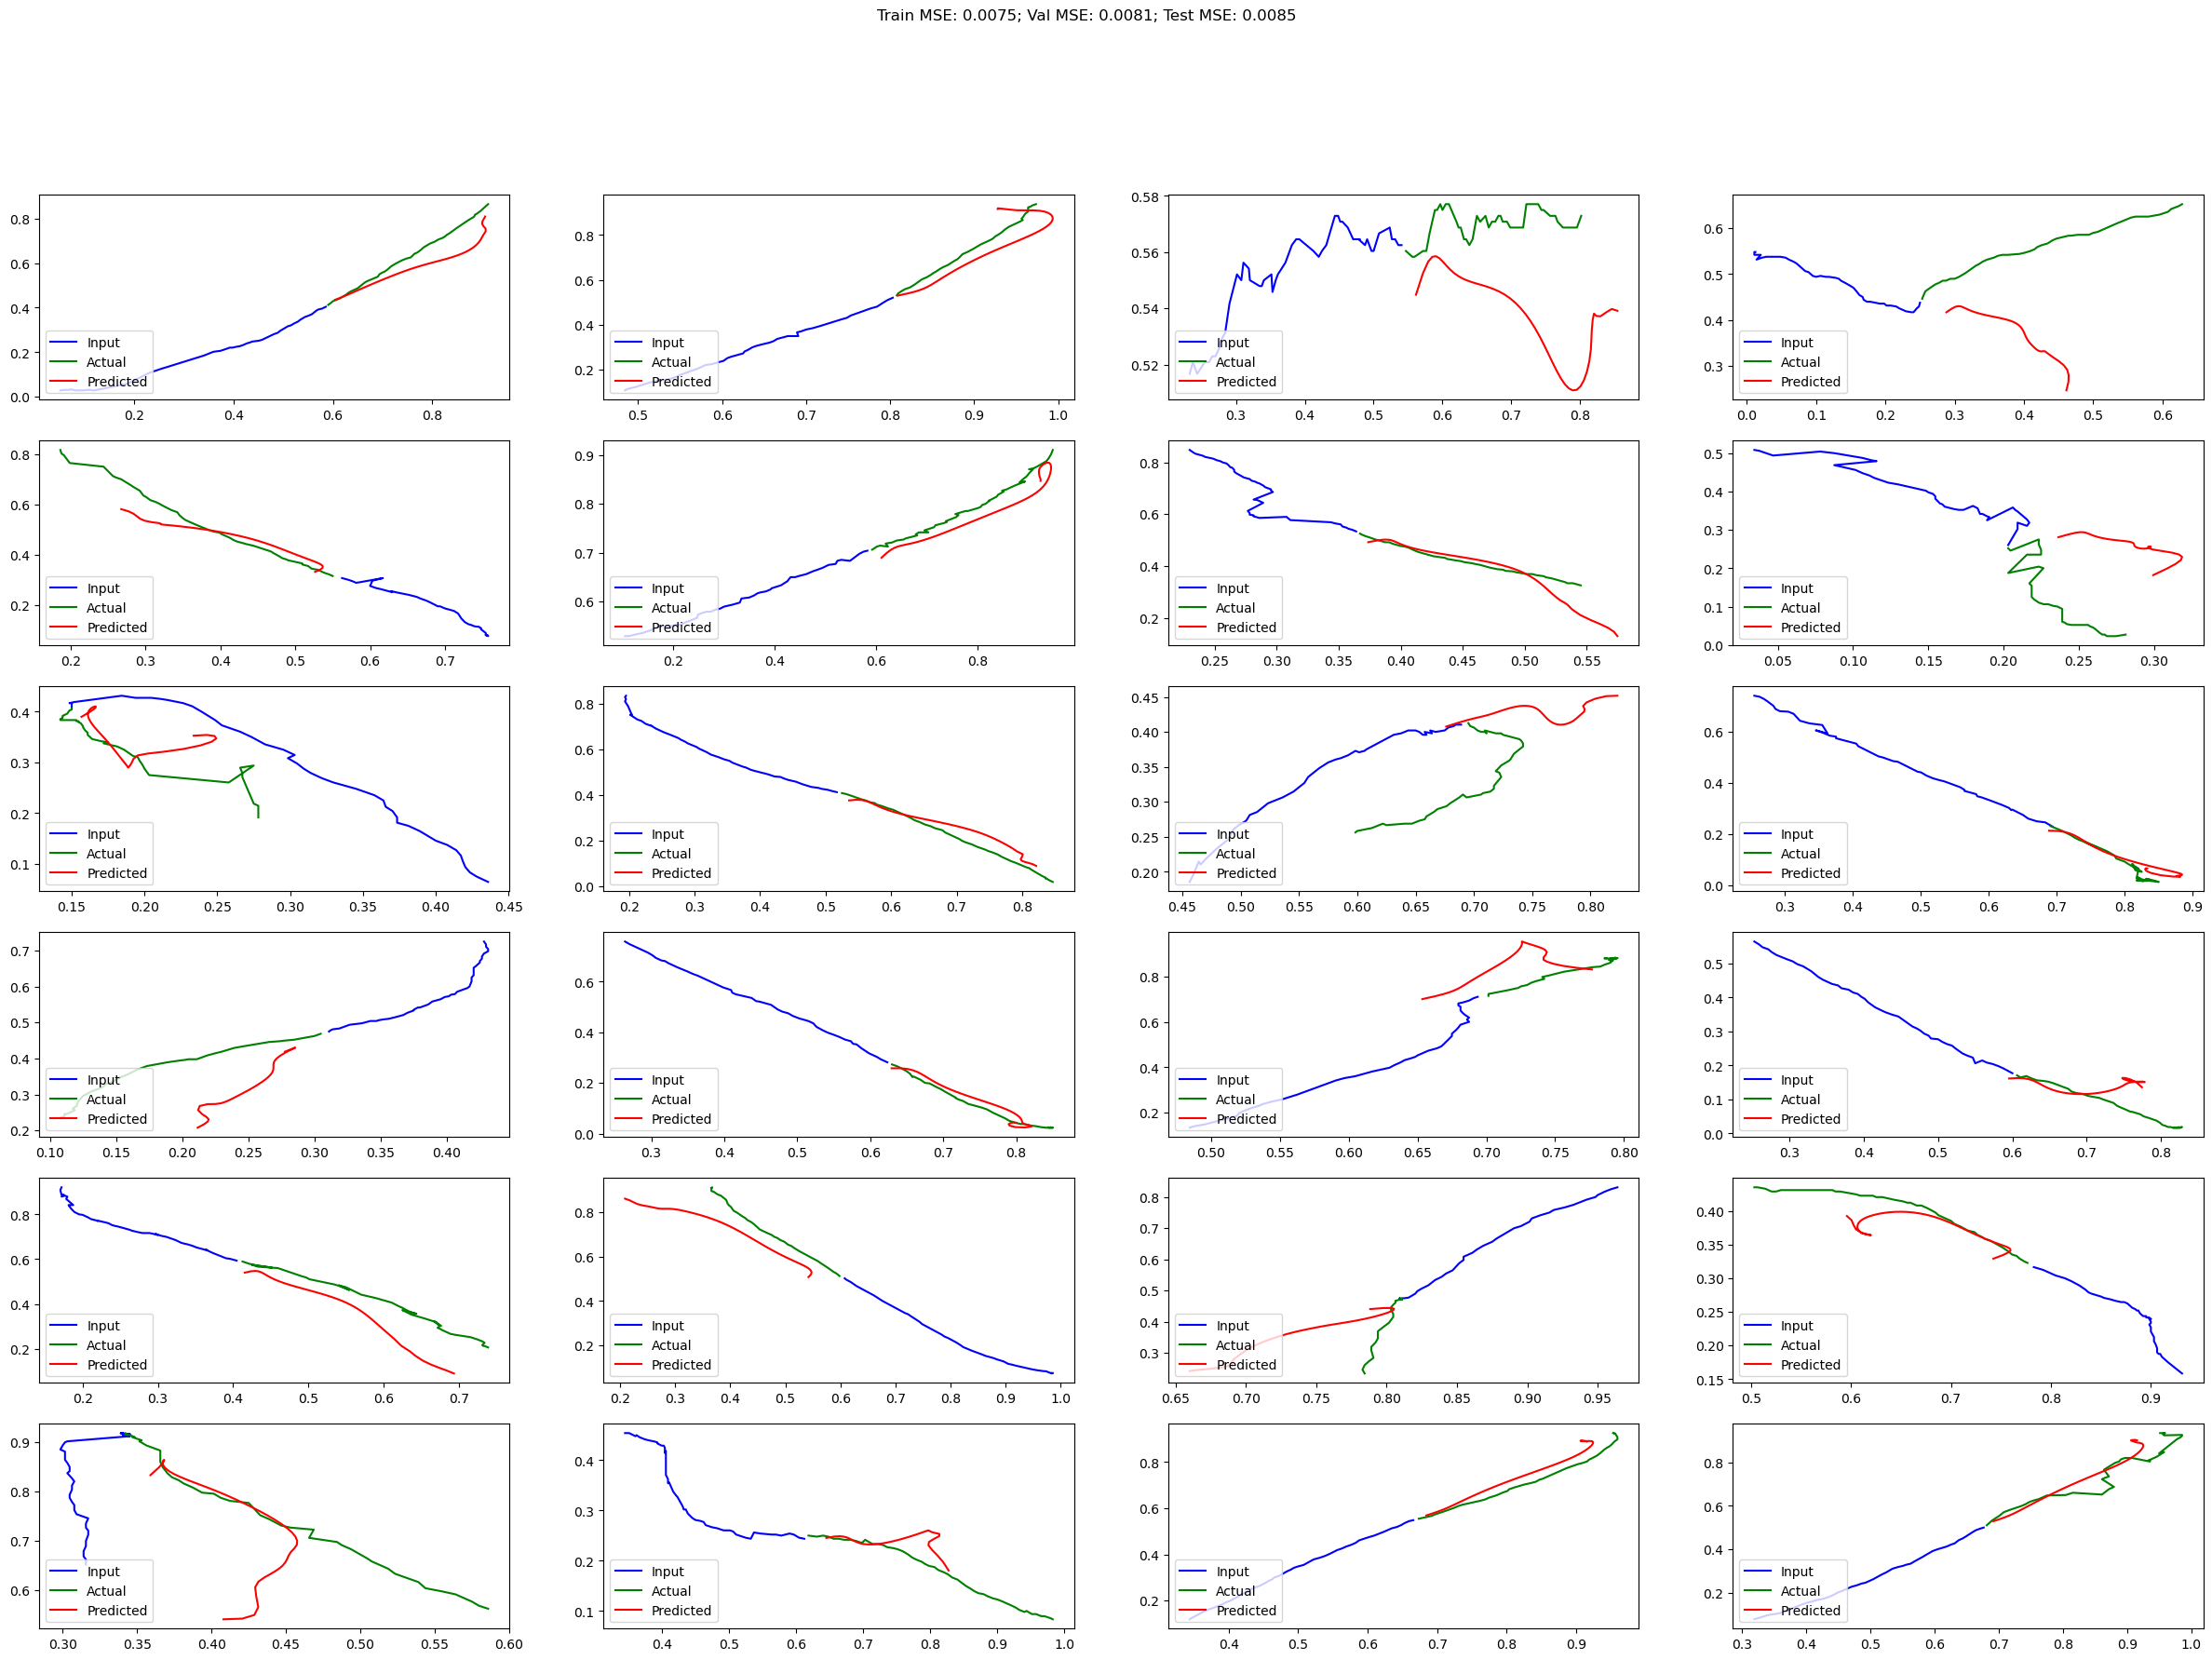

In [29]:
eval_traj_prediction(model_bilstm_att, x_train_seq, y_train_seq, x_val_seq, y_val_seq, x_test_seq, y_test_seq)

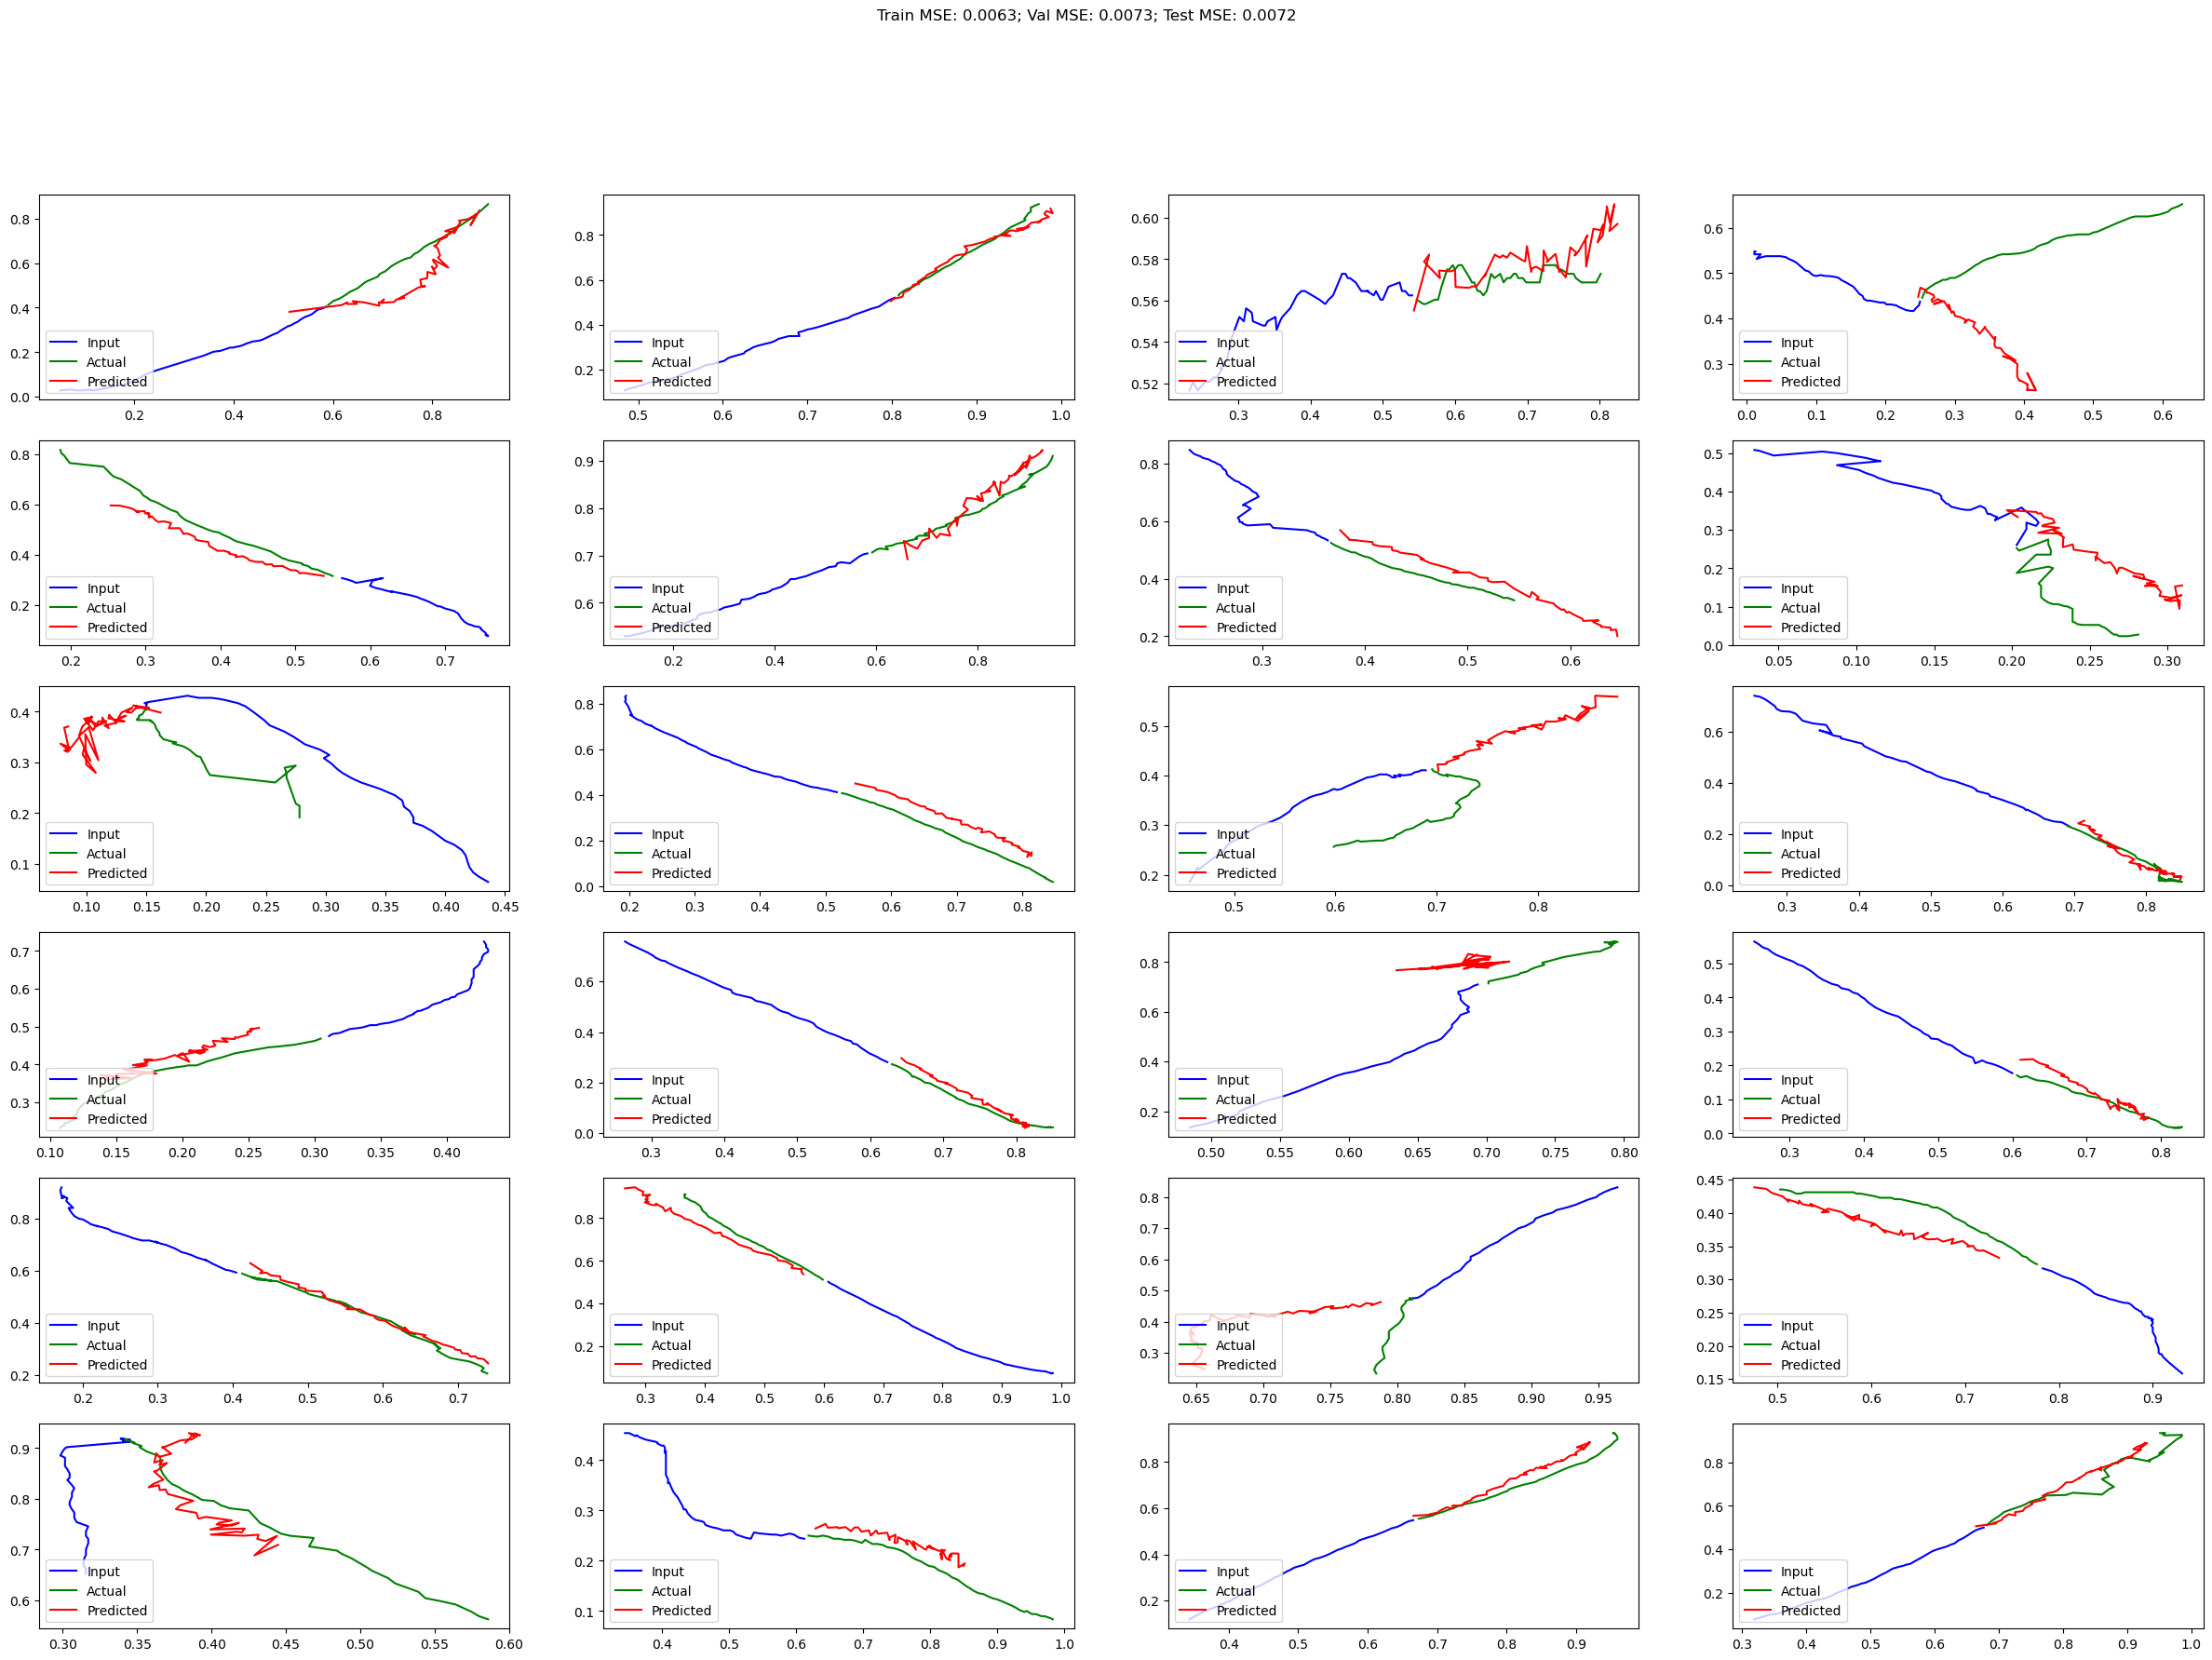

In [30]:
eval_traj_prediction(model_transformer, x_train_seq, y_train_seq, x_val_seq, y_val_seq, x_test_seq, y_test_seq)

This change widens the gap between the transformer and the rest. As sequences get longer, the "memory" part of the LSTM increasingly struggles to keep track of detail across the sequence. We should note that we do still get some weird predictions from our transformer here, with the same high-frequency noise that we saw before. 

Given the performance we're seeing above, it's important to state that (as always it seems) there are other things we could do to improve performance. In particular:
* Embedding sizes are probably not optimal, and architectures themselves could be tweaked in terms of numbers of layers, etc.
* Changes to loss functions could be explored. Other losses such as MAE could be investigated, a term that encourages the predicted trajectory to follow naturally from the observation could be added, smoothness constraints could be included (in particular for the transformer) to help discourage paths that zig-zag, and even adversarial constraints could be added to promote realisitic trajectories.
* More training data could be added.
* Other context information could be included. This could be simple things like the time or day or the day of the week, or it could be information on the location of other pedestrians in the area at the same time. This sort of information could help capture repeating patterns (i.e. people arriving or leaving), or help capture interactions between people as they move.
* Going further down the rabbit hole, considering probabilistic methods that capture the natural multi-modality of pedestrian motion (i.e. that there are multiple plausible and valid paths from A to B) could be considered.

## Final Thoughts

So where does this leave us?

Ultimatley in CAB420 we're not able to use large enough datasets and models to always see the benefits of bigger and better architectures. With our walmart prediction tasks, all models performed fairly similarly, though from a design consideration I'd argue that the transformer gives us a nicer way to include the additional information (i.e. the department who's sales we're predicting) than any of the LSTM models. 

For our second test case, we did see that as we added bells and whilstles to our models, performance improved - though as is often the case there is a sense of diminishing returns with the gain going from the simplest LSTM to the bidirectional LSTM far greater than any additional gains we see as we add attention and go onto the transformer (though gains are larger with the longer sequences). A richer, more complex problem space which might resulting from including more context information (other pedestrians, time of day, day of week, etc) would likely see more gains from the transformer - and incorporating these might also be simpler given the attention driven nature of the model - though it's also the most computationally demanding of the lot.